# Exposure and Bubble breaking results

In [ ]:
import pandas as pd
import numpy as np
import geopandas as gpd
import os
import h3
from shapely.geometry import Polygon
import folium
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from scipy.stats import wilcoxon
from scipy.stats import spearmanr
import json

In [2]:
def weighted_median(values, weights):
    """Compute weighted median"""
    sorted_idx = np.argsort(values)
    sorted_vals = np.array(values)[sorted_idx]
    sorted_weights = np.array(weights)[sorted_idx]
    cum_weights = np.cumsum(sorted_weights)
    cutoff = 0.5 * sum(sorted_weights)
    return sorted_vals[cum_weights >= cutoff][0]

In [89]:
import matplotlib as mpl
from matplotlib import font_manager
import pathlib

font_dir = pathlib.Path.home() / "fonts"

for f in font_dir.glob("*.ttf"):
    font_manager.fontManager.addfont(str(f))

def setup_mpl():

    mpl.rcParams.update({

        # -------------------
        # Fonts (publication safe)
        # -------------------
        "font.family": "Liberation Sans",
        "font.size": 7,          # base text

        "axes.labelsize": 8,
        "axes.titlesize": 8,
        "legend.fontsize": 7,
        "xtick.labelsize": 6,
        "ytick.labelsize": 6,

        # keep text editable in SVG/PDF
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
        "ps.fonttype": 42,

        # -------------------
        # Lines & axes
        # -------------------
        "lines.linewidth": 0.8,
        "axes.linewidth": 0.8,

        # -------------------
        # Ticks (Nature style thin & compact)
        # -------------------
        "xtick.major.width": 0.8,
        "ytick.major.width": 0.8,
        "xtick.minor.width": 0.6,
        "ytick.minor.width": 0.6,

        "xtick.major.size": 3,
        "ytick.major.size": 3,
        "xtick.minor.size": 1.5,
        "ytick.minor.size": 1.5,

        "xtick.major.pad": 2,
        "ytick.major.pad": 2,

        "xtick.top": False,
        "ytick.right": False,

        # -------------------
        # Layout polish
        # -------------------
        "axes.labelpad": 2,
        "mathtext.default": "regular",
        "legend.frameon": False
    })


setup_mpl()


dict_country = {
    "co":"colombia",
    "mx":"mexico",
    "in":"india",
    "id":"indonesia"
}

dict_titles = {
        "5000":"10 min",
        "7500":"15 min",
        "10000":"20 min",
        "15000":"30 min",
        "22500":"45 min",
        "30000":"1 h",
        "60000":"2 h"
}

def h3_to_polygon(h3_hex):
    # Hex string to polygon
    coords = h3.cell_to_boundary(h3_hex)
    flipped = tuple(coord[::-1] for coord in coords)
    return Polygon(flipped)


def get_data(countryID=None):
    countryname = dict_country[countryID]
    case = "pre-covid"
    kind = "empirical"
    df_pre_covid = pd.read_csv("/work/netmob24/data/tmp/" + kind + "_" + case + "_" + countryname + ".csv")
    df_pre_covid["geometry"] = df_pre_covid["cell"].apply(h3_to_polygon)
    gdf_pre_covid = gpd.GeoDataFrame(df_pre_covid, geometry="geometry", crs = "EPSG:4326")
    case = "driving"
    df_driving = pd.read_csv("/work/netmob24/data/tmp/"+ case + "_"+countryname+".csv")
    gdf = pd.merge(gdf_pre_covid, df_driving, on = "cell",how ="inner")
    # Reorganize the data
    gdf = gdf.drop(columns=['Unnamed: 0_x', 'Unnamed: 0_y'])
    gdf.rename(columns=dict_titles, inplace=True)
    gdf = pd.melt(gdf, id_vars=['pre-covid', 'pre-covid_cell', 'cell', 'geometry'],
                value_vars=['10 min', '15 min', '20 min', '30 min', '45 min', '1 h', "2 h"],
                var_name='threshold', value_name='pre-covid_th')
    return gdf


def bootstrap_median(data, n_bootstrap=1000):
    """
    Calculate the median and its standard error from bootstrap samples.

    Parameters:
    - data: array-like, the dataset from which to sample
    - n_bootstrap: int, the number of bootstrap samples to generate

    Returns:
    - median_estimate: float, the median of the original data
    - se_median: float, the standard error of the median from bootstrap samples
    """
    bootstrap_samples = np.random.choice(data, size=(n_bootstrap, len(data)), replace=True)
    medians = np.median(bootstrap_samples, axis=1)
    median_estimate = np.mean(data)
    se_median = np.std(medians)
    return median_estimate, se_median

In [4]:
# Load OD data (keep trip duration and length)
def get_weekly_data(countryID=None):
    df1 = pd.read_csv(f"/work/netmob24/data/OD/weekly/H37/od_week_h37_{countryID}_2019.csv")
    df2 = pd.read_csv(f"/work/netmob24/data/OD/weekly/H37/od_week_h37_{countryID}_2020.csv")
    # Keep only pre-covid data
    df2 = df2[df2["week_number"] < 10] # Only keep the first 10 weeks (pre-covid)
    df = pd.concat([df1, df2], ignore_index=True)

    # Focus on cities
    df = df[df["start_h3_7"].isin(cells2keep)]

    # Consider trips outside the focal cell
    # df = df[df["end_h3_7"] != df["start_h3_7"]]
    # Group and compute weighted medians
    result = df.groupby('start_h3_7').apply(
        lambda g: pd.Series({
            'wm_duration_min': weighted_median(g['m_duration_min'], g['trip_count']),
            'wm_length_m': weighted_median(g['mdn_length_m'], g['trip_count']) / 1000,  # Convert to km
        }), include_groups=False
    ).reset_index()
    return result.rename(columns={"start_h3_7": "cell"})

## Get cities

In [5]:
gdf = gpd.read_file('/work/netmob24/data/cities/cities.geojson')
gdf = gdf[gdf['country'] != "colombia"]
cells2keep = gdf["cell"].unique()
gdf_info = gpd.read_file('/work/netmob24/data/cities/cities_info.geojson')
gdf = pd.merge(gdf, gdf_info.drop(columns=['geometry']), on = "name_city", how = "left")
cities = gdf["correct_name"].unique()
name_to_country = dict(zip(gdf['correct_name'], gdf['country']))
gdf.head()

,cell,component,country,key,name_city,geometry,correct_name,population,area_km2,pop_density
0,8729a4c2affffff,0,mexico,mexico0,Tijuana,"POLYGON ((-116.93595 32.4931, -116.928 32.5049...",Tijuana,2.954140e+06,547.137308,5399.267006
1,8729a4d51ffffff,0,mexico,mexico0,Tijuana,"POLYGON ((-117.00771 32.43297, -116.99978 32.4...",Tijuana,2.954140e+06,547.137308,5399.267006
2,8729a4d59ffffff,0,mexico,mexico0,Tijuana,"POLYGON ((-117.05616 32.47885, -117.04824 32.4...",Tijuana,2.954140e+06,547.137308,5399.267006
3,8729a4d08ffffff,0,mexico,mexico0,Tijuana,"POLYGON ((-116.93517 32.37582, -116.92723 32.3...",Tijuana,2.954140e+06,547.137308,5399.267006
4,8729a4c65ffffff,0,mexico,mexico0,Tijuana,"POLYGON ((-117.10445 32.50124, -117.09653 32.5...",Tijuana,2.954140e+06,547.137308,5399.267006


### Compactness

In [6]:
gdf = gdf[['cell', 'correct_name', 'country', 'pop_density', 'population', 'geometry']] # pop_density, population are at the city level

def lonlat_to_utm_epsg(lon, lat):
    """Infer UTM EPSG based on centroid lon/lat"""
    zone = int((lon + 180) / 6) + 1
    if lat >= 0:
        return 32600 + zone  # Northern Hemisphere
    else:
        return 32700 + zone  # Southern Hemisphere

def compute_city_compactness_auto_utm(gdf, city_col='city'):
    results = []

    # Ensure input is in WGS84
    gdf = gdf.to_crs("EPSG:4326")

    for city, city_gdf in gdf.groupby(city_col):
        # Compute centroid of all geometries
        centroid = city_gdf.geometry.unary_union.centroid
        lon, lat = centroid.x, centroid.y

        # Determine UTM EPSG
        epsg = lonlat_to_utm_epsg(lon, lat)

        # Project to local UTM CRS
        city_proj = city_gdf.to_crs(epsg=epsg)

        # Union of hexagons for this city
        geom_union = city_proj.geometry.unary_union

        # Compute area and perimeter
        area = geom_union.area
        perimeter = geom_union.length

        # Compactness
        compactness = (4 * np.pi * area) / (perimeter ** 2)

        results.append({
            city_col: city,
            'epsg': epsg,
            'area_m2': area,
            'perimeter_m': perimeter,
            'compactness': compactness
        })

    return gpd.GeoDataFrame(results)

def assign_compactness_cluster_within_country(group):
    median_c = group['compactness'].median()
    def cluster(row):
        if row['compactness'] <= median_c:
            return 1
        elif row['compactness'] > median_c:
            return 2

    group['Cluster'] = group.apply(cluster, axis=1)
    return group


df_metrics = compute_city_compactness_auto_utm(gdf, city_col='correct_name')
df_metrics = pd.merge(df_metrics[['correct_name', 'compactness']], 
                      gdf[['correct_name', 'country', 'pop_density', 'population']].drop_duplicates(subset=['correct_name']), 
                      left_on='correct_name', right_on='correct_name', how='left')


df_metrics_c = df_metrics.groupby('country', group_keys=False).apply(assign_compactness_cluster_within_country)

cluster_name_dict = {
    2: "Compact",
    1: "Sparse",
}
df_metrics_c['Cluster_c'] = df_metrics_c['Cluster'].map(cluster_name_dict)
print(df_metrics_c.sort_values('compactness'))

/tmp/ipykernel_127032/2592751199.py:19: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  centroid = city_gdf.geometry.unary_union.centroid
/tmp/ipykernel_127032/2592751199.py:29: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  geom_union = city_proj.geometry.unary_union


           correct_name  compactness    country   pop_density    population  \
19  Greater Mexico City     0.066986     mexico   8012.457375  2.441359e+07   
61                Thane     0.075048      india   8226.689316  7.550907e+06   
58             Surabaya     0.094591  indonesia   9644.430213  7.132354e+06   
64               Toluca     0.107505     mexico   5655.007157  4.613274e+06   
28             Jarkarta     0.110554  indonesia  10372.323983  2.893304e+07   
..                  ...          ...        ...           ...           ...   
60                Surat     0.456249      india   9599.918766  2.225860e+06   
62   Thiruvananthapuram     0.517309      india   9575.655485  1.404989e+06   
67             Vadodara     0.540394      india  10247.025102  1.707211e+06   
35             Ludhiana     0.572110      india  12230.728948  2.314525e+06   
37            Matamoros     0.588317     mexico   6315.071977  9.766193e+05   

    Cluster Cluster_c  
19        1    Sparse  
61 

/tmp/ipykernel_127032/2592751199.py:66: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_metrics_c = df_metrics.groupby('country', group_keys=False).apply(assign_compactness_cluster_within_country)


In [7]:
# Create a folium map centered around the data
city2show = "Tijuana" # 'Ludhiana'
gdf2plot = gdf[gdf["correct_name"]==city2show]
print(gdf2plot['country'].unique()[0], city2show)
m = folium.Map(location=[gdf2plot.geometry.centroid.y.mean(), gdf2plot.geometry.centroid.x.mean()],
               zoom_start=12,
               tiles="CartoDB positron")  # or "OpenStreetMap", "Stamen Terrain", etc.

# Add the GeoDataFrame to the map
folium.GeoJson(
    gdf2plot,
    name='GeoData',
    tooltip=folium.GeoJsonTooltip(fields=gdf2plot.columns.difference(['geometry']).tolist())
).add_to(m)

# Add layer control (optional)
folium.LayerControl().add_to(m)
m

mexico Tijuana


/tmp/ipykernel_127032/2119743948.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  m = folium.Map(location=[gdf2plot.geometry.centroid.y.mean(), gdf2plot.geometry.centroid.x.mean()],


## 1. Descriptive results
Residential, gravity-based, empirical deprivation levels

In [8]:
def add_deprivation_groups_residential_th_interq(gdf=None, num_grp=None):
    gdf.loc[:, 'grp_cell'] = pd.qcut(gdf.loc[:, 'pre-covid_cell'], q=num_grp, labels=[i for i in range(1, num_grp + 1)])
    gdf.loc[:, 'grp_cell'] = gdf.loc[:, 'grp_cell'].astype(float)
    def grp_stats(data):
        return pd.Series(dict(d_50_r=data["pre-covid_cell"].median(),
                            d_25_r=data["pre-covid_cell"].quantile(0.25),
                            d_75_r=data["pre-covid_cell"].quantile(0.75),
                            d_50_th=data["pre-covid_th"].median(),
                            d_25_th=data["pre-covid_th"].quantile(0.25),
                            d_75_th=data["pre-covid_th"].quantile(0.75),
                            d_50=data["pre-covid"].median(),
                            d_25=data["pre-covid"].quantile(0.25),
                            d_75=data["pre-covid"].quantile(0.75)))
    gdf_g = gdf.groupby(['grp_cell', 'threshold']).apply(grp_stats, include_groups=False).reset_index()
    return gdf_g

def add_deprivation_groups_residential_th_md(gdf=None, num_grp=None):
    gdf.loc[:, 'grp_cell'] = pd.qcut(gdf.loc[:, 'pre-covid_cell'], q=num_grp, labels=[i for i in range(1, num_grp + 1)])
    gdf.loc[:, 'grp_cell'] = gdf.loc[:, 'grp_cell'].astype(float)
    def grp_stats(data):
        md_r, md_err_r = bootstrap_median(data["pre-covid_cell"], n_bootstrap=1000)
        md_th, md_err_th = bootstrap_median(data["pre-covid_th"], n_bootstrap=1000)
        md, md_err = bootstrap_median(data["pre-covid"], n_bootstrap=1000)
        return pd.Series(dict(d_50_r=md_r,
                              d_err_r = md_err_r,
                              d_50_th=md_th,
                              d_err_th=md_err_th,
                              d_50=md,
                              d_err=md_err))
    gdf_g = gdf.groupby(['grp_cell', 'threshold'], observed=True).apply(grp_stats, include_groups=False).reset_index()
    return gdf_g

def deprivation_exposure_data(countryID=None):
    gdf = get_data(countryID=countryID)
    return add_deprivation_groups_residential_th_md(gdf=gdf, num_grp=30)


### 1.1 Save the figures of deprivation data (45 min)

In [ ]:
for countryID in ("co", "id", "in", "mx"):
    print(dict_country[countryID])
    gdf_original = get_data(countryID=countryID)
    gdf_original.rename(columns={'pre-covid': 'Empirical', 'pre-covid_cell': 'Residential', 'pre-covid_th': 'Theoretical'}, inplace=True)
    # Focus on cities
    gdf_original = gdf_original[gdf_original['cell'].isin(cells2keep)]
    threshold = '45 min'
    # Conversion from cm to inches (1 inch = 2.54 cm)
    cm_to_inch = 1 / 2.54
    figsize_cm = (10, 10)  # 5 cm x 5 cm
    figsize_inch = tuple(cm * cm_to_inch for cm in figsize_cm)
    g = sns.PairGrid(gdf_original.loc[gdf_original['threshold'] == threshold, ['Residential', 'Theoretical', 'Empirical']], 
                    diag_sharey=False,
                    height=figsize_inch[1]/3)  # height controls each individual subplot
    g.map_upper(sns.scatterplot, s=1, alpha=0.5)
    g.map_lower(sns.kdeplot, linewidths=0.5)
    g.map_diag(sns.kdeplot, lw=1)
    g.savefig(f"../figures/exposure_{dict_country[countryID]}_{threshold}.png", dpi=300, bbox_inches='tight')

In [ ]:
# df = deprivation_exposure_data(countryID=countryID)

## 2. Bubble breaking results

In [9]:
def bubble_breaking_data(gdf=None, num_grp=None):
    gdf.loc[:, 'grp_cell'] = pd.qcut(gdf.loc[:, 'Residential'], q=num_grp, labels=[i for i in range(1, num_grp + 1)])
    gdf.loc[:, 'grp_cell'] = gdf.loc[:, 'grp_cell'].astype(float)
    def grp_stats(data):
        md_e, md_err_e = bootstrap_median(data["bb_e"], n_bootstrap=1000)
        md_t, md_err_t = bootstrap_median(data["bb_t"], n_bootstrap=1000)
        md_g, md_err_g = bootstrap_median(data["bb_g"], n_bootstrap=1000)
        return pd.Series(dict(r=data["Residential"].median(),
                              bbt_50=md_t,
                              bbt_err=md_err_t,
                              bbe_50=md_e,
                              bbe_err=md_err_e,
                              bbg_50=md_g,
                              bbg_err=md_err_g))
    gdf_g = gdf.groupby(['grp_cell', 'threshold'], observed=True).apply(grp_stats, include_groups=False).reset_index()
    return gdf_g

In [10]:
def plot_bb_by_group(gdf_g=None, countryID=None, threshold=None):
    data = gdf_g.loc[gdf_g['threshold'] == threshold].copy()
    fig = plt.figure(figsize=(10, 5),dpi = 200)
    ax = fig.add_subplot(1,1,1)
    # Calculate the error values
    yerr_e = [data["bbe_err"], data["bbe_err"]]
    yerr_t = [data["bbt_err"], data["bbe_err"]]
    yerr_g = [[data["bbg_err"], data["bbg_err"]]]
    offset = 0.25
    x_values = data["r"]
    # Plot the error bars
    # Plot the first set of error bars (Residential)
    ax.errorbar(
        x_values - offset,  # Shift x-values left
        data["bbe_50"], 
        yerr=yerr_e, 
        fmt='o', 
        capsize=2, 
        label="Bubble breaking (empirical)", 
        color='darkred',
        markersize=1
    )

    # Plot the second set of error bars (Empirical)
    ax.errorbar(
        x_values + offset,  # Shift x-values right
        data["bbt_50"], 
        yerr=yerr_t, 
        fmt='o', 
        capsize=2, 
        label="Bubble breaking (theoretical)", 
        color='steelblue',
        markersize=1
    )

    # Plot the second set of error bars (Theoretical)
    #ax.errorbar(
    #    x_values,    # + offset,  # Shift x-values right
    #    data["bbg_50"], 
    #    yerr=yerr_g, 
    #    fmt='x', 
    #    capsize=7, 
    #    label="Bubble breaking (gap)", 
    #    color='coral',
    #    markersize=1
    #)

    ax.set_xlabel("Deprivation")
    ax.set_ylabel("Bubble breaking indicators")
    #ax.set_ylim([0,70])
    #ax.set_xlim([-2, num_grp +2])
    ax.legend()
    #ax.plot(np.linspace(1,100),np.linspace(1,100),color = "grey")
    ax.set_title(dict_country[countryID])


In [11]:
def bubble_breaking_plot(df_b=None, threshold="45 min", count_threshold = 3, countryID=None):
    data = df_b.loc[df_b['threshold'] == threshold].copy()
    fig = plt.figure(figsize=(60/24.5, 60/24.5), dpi = 300)
    ax = fig.add_subplot(1,1,1)
    # Calculate the error values
    yerr_e = [data["bbe_err"], data["bbe_err"]]
    yerr_t = [data["bbt_err"], data["bbt_err"]]
    offset = 0.25
    x_values = data["r"]
    #######
    # Data subset
    df2plot = gdf_original.loc[gdf_original['threshold'] == threshold, ['Residential', 'bb_e']]

    x = df2plot['Residential'].values
    y = df2plot['bb_e'].values

    # Stack x and y into a 2D array for KDE
    xy = np.vstack([x, y])
    # KDE
    kde = gaussian_kde(xy)

    # Create a grid with a small buffer around the data range
    buffer = 0.1  # or adjust as needed
    x_min, x_max = x.min() - buffer, x.max() + buffer
    y_min, y_max = y.min() - buffer, y.max() + buffer

    xgrid = np.linspace(x_min, x_max, 100)
    ygrid = np.linspace(y_min, y_max, 100)
    X, Y = np.meshgrid(xgrid, ygrid)
    positions = np.vstack([X.ravel(), Y.ravel()])

    # Evaluate KDE
    Z = kde(positions).reshape(X.shape)

    # Optional: Mask extremely low density regions to avoid shading flat areas
    Z[Z < Z.max() * 0.005] = np.nan  # Mask values below 1% of max

    # Plot filled contour
    ax.contourf(X, Y, Z, levels=15, cmap='Blues', alpha=0.2)
    #########
    # Plot the error bars
    # Plot the first set of error bars (Residential)
    ax.errorbar(
        x_values - offset,  # Shift x-values left
        data["bbe_50"], 
        yerr=yerr_e, 
        fmt='o', 
        capsize=2, 
        label="Empirical", 
        color='#0fbcf9',
        markersize=1
    )
    ax.errorbar(
        x_values - offset,  # Shift x-values left
        data["bbt_50"],
        yerr=yerr_t, 
        fmt='o', 
        capsize=2, 
        label="Gravity", 
        color='#05c46b',
        markersize=1
    )
    sns.despine(ax=ax)
    # Draw horizontal line at y=0
    ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_title(dict_country[countryID].capitalize())
    ax.set_xlabel("Residential deprivation")
    ax.set_ylabel("Bubble breaking indicators")
    ax.set_xlim([min(data['r']) - 5, max(data['r'] + 5)])
    ax.set_ylim([min(data['bbe_50']) - 10, max(data['bbt_50']) + 10])
    ax.legend(loc='upper left', frameon=False)
    # ax.set_title(dict_country[countryID])
    fig.savefig(f"../figures/bb_{dict_country[countryID]}_{threshold}.pdf", dpi=600, facecolor="white")

india
Empirical
Spearman correlation: 0.446, p-value: 2.643e-47
Spearman correlation: -0.092, p-value: 3.518e-03
Wilcoxon statistic: 1028399.500
P-value: 1.631e-03
Theoretical
Wilcoxon statistic: 687417.000
P-value: 1.000e+00
Test whether bb_e_values are greater than bb_t_values
Wilcoxon statistic: 1305187.000, p-value: 3.708e-44
BBG vs. Residential deprivation
Spearman correlation: 0.153, p-value: 1.083e-11
mexico
Empirical
Spearman correlation: 0.596, p-value: 3.582e-166
Spearman correlation: 0.097, p-value: 4.176e-03
Wilcoxon statistic: 2548222.000
P-value: 5.449e-111
Theoretical
Wilcoxon statistic: 769890.000
P-value: 1.000e+00
Test whether bb_e_values are greater than bb_t_values
Wilcoxon statistic: 3334111.000, p-value: 0.000e+00
BBG vs. Residential deprivation
Spearman correlation: 0.150, p-value: 1.598e-14


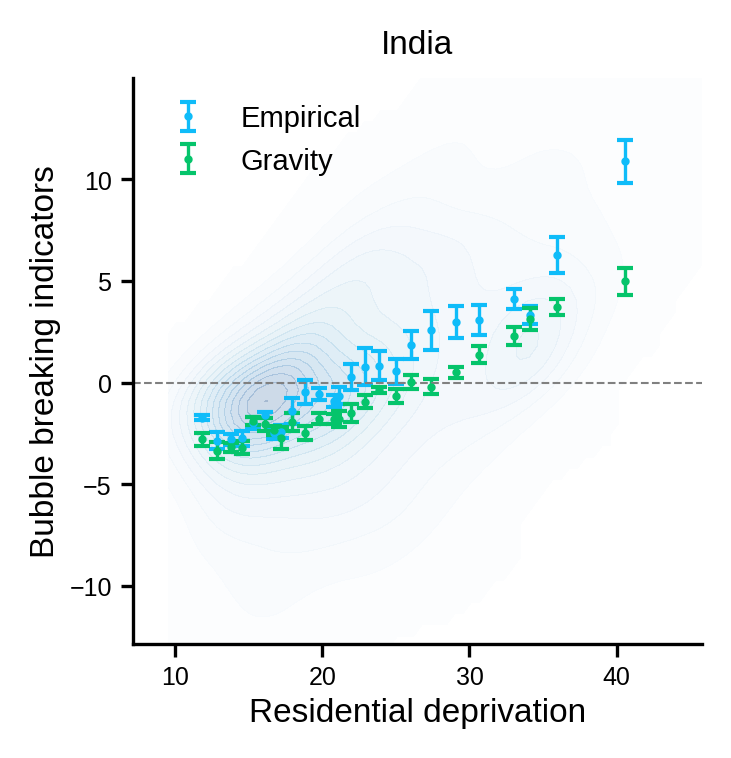

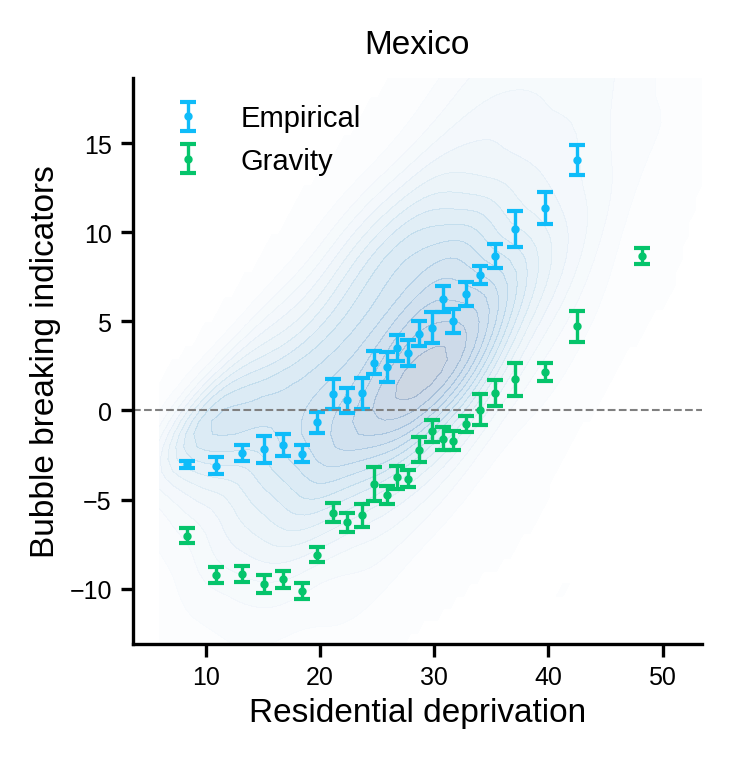

In [20]:
for countryID in ("in", "mx"): # "co" is dropped due to lack of enough data
    print(dict_country[countryID])
    gdf_original = get_data(countryID=countryID)
    # Focus on cities
    gdf_original = gdf_original[gdf_original['cell'].isin(cells2keep)]
    gdf_original.rename(columns={'pre-covid': 'Empirical', 'pre-covid_cell': 'Residential', 'pre-covid_th': 'Theoretical'}, inplace=True)
    gdf_original.loc[:, 'bb_e'] = gdf_original.loc[:, 'Residential'] - gdf_original.loc[:, 'Empirical']
    gdf_original.loc[:, 'bb_t'] = gdf_original.loc[:, 'Residential'] - gdf_original.loc[:, 'Theoretical']
    gdf_original.loc[:, 'bb_g'] = gdf_original.loc[:, 'Theoretical'] - gdf_original.loc[:, 'Empirical']
    df_b = bubble_breaking_data(gdf=gdf_original, num_grp=25)
    # Statistical test
    threshold = '45 min'
    # Drop NaNs if any
    print('Empirical')
    bb_e_values = gdf_original[gdf_original['threshold'] == threshold]['bb_e'].dropna()
    # Positive - strong breaking
    r_values = gdf_original[(gdf_original['threshold'] == threshold) & (gdf_original['bb_e'] > 0)]['Residential'].dropna()
    bb_e_values2test = gdf_original[(gdf_original['threshold'] == threshold) & (gdf_original['bb_e'] > 0)]['bb_e'].dropna()
    print(f"Spearman correlation: {spearmanr(bb_e_values2test, r_values).correlation:.3f}, p-value: {spearmanr(bb_e_values2test, r_values).pvalue:.3e}")
    # Negative
    r_values = gdf_original[(gdf_original['threshold'] == threshold) & (gdf_original['bb_e'] < 0)]['Residential'].dropna()
    bb_e_values2test = gdf_original[(gdf_original['threshold'] == threshold) & (gdf_original['bb_e'] < 0)]['bb_e'].dropna()
    print(f"Spearman correlation: {spearmanr(bb_e_values2test, r_values).correlation:.3f}, p-value: {spearmanr(bb_e_values2test, r_values).pvalue:.3e}")
    # Perform two-sided Wilcoxon test against 0
    stat, p_value = wilcoxon(bb_e_values, alternative='greater', zero_method='wilcox')

    print(f"Wilcoxon statistic: {stat:.3f}")
    print(f"P-value: {p_value:.3e}")
    print('Theoretical')
    bb_t_values = gdf_original[gdf_original['threshold'] == threshold]['bb_t'].dropna()

    # Perform two-sided Wilcoxon test against 0
    stat, p_value = wilcoxon(bb_t_values, alternative='greater', zero_method='wilcox')

    print(f"Wilcoxon statistic: {stat:.3f}")
    print(f"P-value: {p_value:.3e}")

    # See of bbe > bbt
    print("Test whether bb_e_values are greater than bb_t_values")
    stat, p_value = wilcoxon(bb_e_values, bb_t_values, alternative='greater')
    print(f"Wilcoxon statistic: {stat:.3f}, p-value: {p_value:.3e}")

    # BBG vs. residential correlation
    r_values = gdf_original[(gdf_original['threshold'] == threshold)]['Residential'].dropna()
    bb_g_values2test = gdf_original[(gdf_original['threshold'] == threshold)]['bb_g'].dropna()
    print("BBG vs. Residential deprivation")
    print(f"Spearman correlation: {spearmanr(bb_g_values2test, r_values).correlation:.3f}, p-value: {spearmanr(bb_g_values2test, r_values).pvalue:.3e}")

    bubble_breaking_plot(df_b=df_b, threshold="45 min", count_threshold = 3, countryID=countryID)

In [40]:
for countryID in ("in", "mx"): # "co" is dropped due to lack of enough data
    print(dict_country[countryID])
    gdf_original = get_data(countryID=countryID)
    # Focus on cities
    gdf_original = gdf_original[gdf_original['cell'].isin(cells2keep)]
    gdf_original.rename(columns={'pre-covid': 'Empirical', 'pre-covid_cell': 'Residential', 'pre-covid_th': 'Theoretical'}, inplace=True)
    gdf_original.loc[:, 'bb_e'] = gdf_original.loc[:, 'Residential'] - gdf_original.loc[:, 'Empirical']
    gdf_original.loc[:, 'bb_t'] = gdf_original.loc[:, 'Residential'] - gdf_original.loc[:, 'Theoretical']
    gdf_original.loc[:, 'bb_g'] = gdf_original.loc[:, 'Theoretical'] - gdf_original.loc[:, 'Empirical']
    df_b = bubble_breaking_data(gdf=gdf_original, num_grp=25)
    # Statistical test
    threshold = '45 min'
    bb_g_values = gdf_original[gdf_original['threshold'] == threshold]['bb_g'].dropna()
    # Perform two-sided Wilcoxon test against 0
    stat, p_value = wilcoxon(bb_g_values, alternative='greater', zero_method='wilcox')

    print(f"Wilcoxon statistic: {stat:.3f}")
    print(f"P-value: {p_value:.3e}")

india
Wilcoxon statistic: 1305187.000
P-value: 3.708e-44
mexico
Wilcoxon statistic: 3334111.000
P-value: 0.000e+00


### 2.1 Distributions

In [12]:
def plot_bbg_reverse_cdf(
    df,
    col="bb_g",
    savepath=None,
    title=None,
    color="tab:blue",
    label=None,
    figsize_mm=60,
    annotate_left=True,
):
    fig, ax = plt.subplots(
        figsize=(figsize_mm / 25.4, figsize_mm / 25.4),
        dpi=300
    )

    # ---- data ----
    data = df[col].dropna().to_numpy()
    if data.size == 0:
        raise ValueError(f"No non-null values found in df['{col}'].")

    data = np.sort(data)
    n = data.size
    cdf = np.arange(1, n + 1) / n
    rev_cdf = 1 - cdf

    # ---- main curve ----
    ax.plot(data, rev_cdf, color=color, lw=1.3, label=(label or col))

    # ---- reference line at x=0 ----
    ax.axvline(0, color="black", lw=0.5, ls="--", alpha=0.5)

    # ---- fraction > 0 (reverse CDF at x=0) ----
    frac_pos = 1 - (np.searchsorted(data, 0, side="right") / n)

    ax.axhline(frac_pos, color=color, lw=0.8, ls="--", alpha=0.6)

    # annotate
    x_text = ax.get_xlim()[0] if annotate_left else 0
    ax.text(
        x_text,
        frac_pos + 0.02,
        f"{frac_pos*100:.1f}%",
        color=color,
        va="bottom",
        ha="left"
    )

    # ---- aesthetics ----
    if title is not None:
        ax.set_title(title)

    ax.set_xlabel("Residual bubble breaking")
    ax.set_ylabel("Fraction of areas > x")
    ax.set_ylim(0, 1)

    # only show legend if label provided or you want it
    if label is not None:
        ax.legend(frameon=False, loc="upper right")

    sns.despine(ax=ax)
    plt.tight_layout()

    # ---- save/show ----
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        fig.savefig(savepath, dpi=600, facecolor="white")
        print(f"✅ Figure saved to: {savepath}")
    else:
        plt.show()

    return fig, ax

In [13]:
def plot_bbg_reverse_cdf(df, col="bb_g", bins=50, savepath=None, title=None, color=None):
    """
    Plot reverse cumulative (1 - CDF) distributions of bubble-breaking indicators
    and shade the area where values > 0.
    """
    fig, ax = plt.subplots(figsize=(60/24.5, 60/24.5), dpi=300)

    for col, color, label in zip(cols, colors, labels):
        data = np.sort(df[col].dropna())
        cdf = np.arange(1, len(data) + 1) / len(data)
        rev_cdf = 1 - cdf  # <-- reverse cumulative
        ax.plot(data, rev_cdf, color=color, lw=1.3, label=label)

    # --- Shade area above 0 ---
    ax.axvline(0, color="black", lw=0.5, ls="--", alpha=0.5)


    # --- Add horizontal line at intersection with x=0 ---
    for col, color in zip(cols, colors):
        data = np.sort(df[col].dropna())
        cdf = np.arange(1, len(data) + 1) / len(data)
        rev_cdf = 1 - cdf
        # Find reverse cumulative value at x=0 (fraction > 0)
        y_intersect = 1 - (np.searchsorted(data, 0, side="right") / len(data))
        ax.axhline(y_intersect, color=color, lw=0.8, ls="--", alpha=0.6)
        # Annotate fraction above 0
        ax.text(ax.get_xlim()[0], y_intersect + 0.02,
                f"{y_intersect*100:.1f}%", color=color, fontsize=6, va="bottom")

    # --- Aesthetics ---
    ax.set_title(title)
    ax.set_xlabel("Residual bubble-breaking indicator")
    ax.set_ylabel("Fraction of areas > x")
    ax.set_ylim(0, 1)
    ax.legend(frameon=False, fontsize=7, loc="upper right")
    sns.despine(ax=ax)
    plt.tight_layout()

    # --- Save or show ---
    if savepath:
        os.makedirs(os.path.dirname(savepath), exist_ok=True)
        fig.savefig(
            savepath,
            dpi=600,
            facecolor="white"
        )
        print(f"✅ Figure saved to: {savepath}")
    else:
        plt.show()

    return fig, ax

india
✅ Figure saved to: ../figures/bb_distr_india_45 min.pdf
✅ Figure saved to: ../figures/bbg_distr_india_45 min.pdf
mexico
✅ Figure saved to: ../figures/bb_distr_mexico_45 min.pdf
✅ Figure saved to: ../figures/bbg_distr_mexico_45 min.pdf


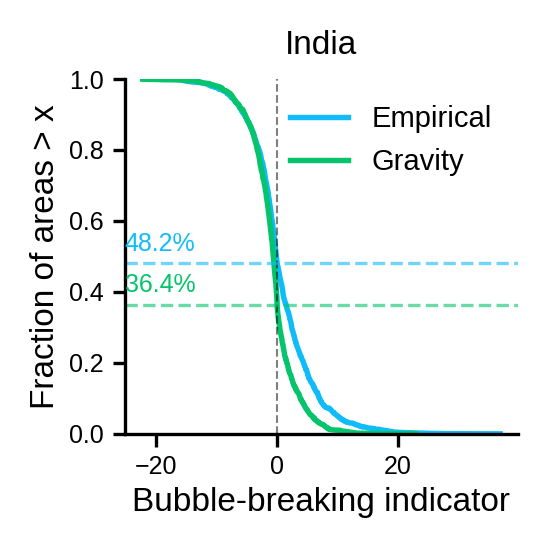

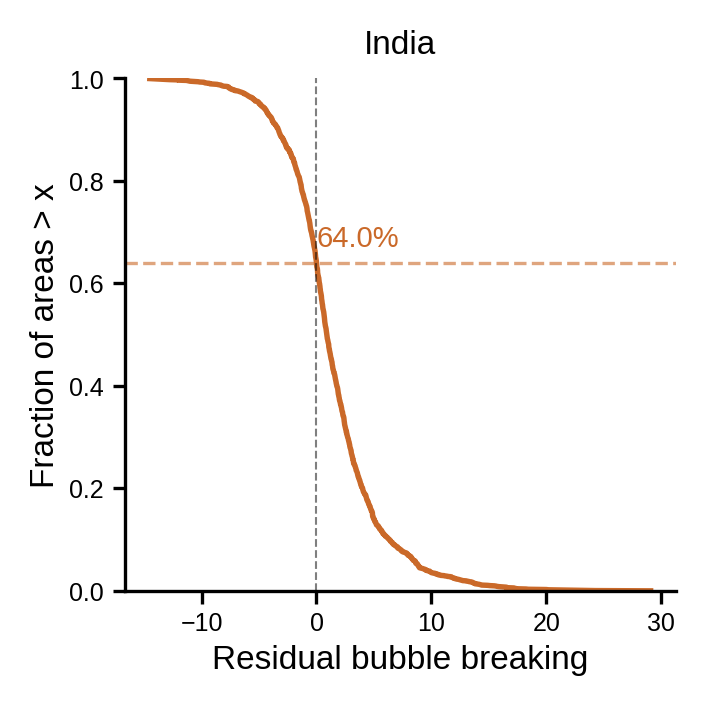

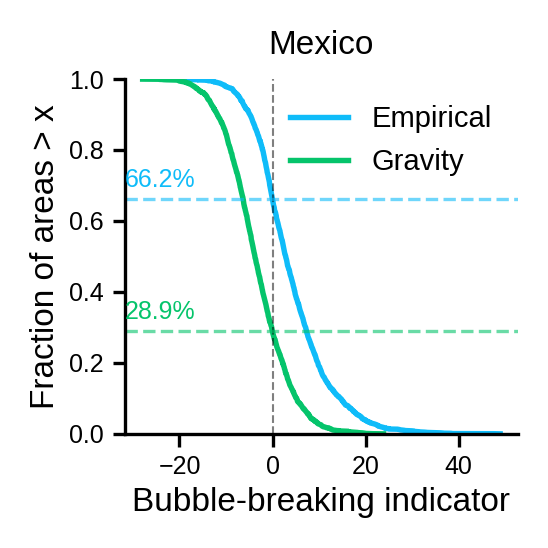

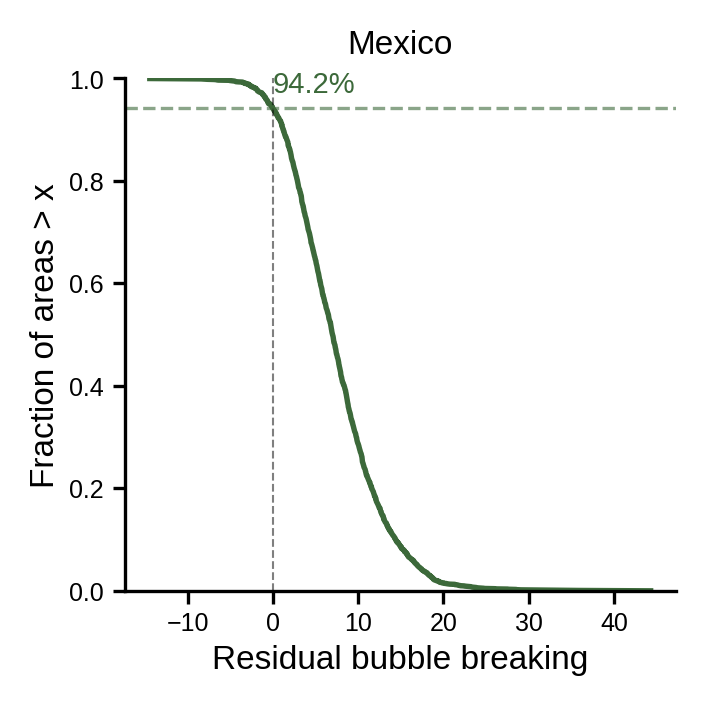

In [39]:
for countryID in ("in", "mx"): # "co" is dropped due to lack of enough data
    print(dict_country[countryID])
    gdf_original = get_data(countryID=countryID)
    # Focus on cities
    gdf_original = gdf_original[gdf_original['cell'].isin(cells2keep)]
    gdf_original.rename(columns={'pre-covid': 'Empirical', 'pre-covid_cell': 'Residential', 'pre-covid_th': 'Theoretical'}, inplace=True)
    gdf_original.loc[:, 'bb_e'] = gdf_original.loc[:, 'Residential'] - gdf_original.loc[:, 'Empirical']
    gdf_original.loc[:, 'bb_t'] = gdf_original.loc[:, 'Residential'] - gdf_original.loc[:, 'Theoretical']
    gdf_original.loc[:, 'bb_g'] = gdf_original.loc[:, 'Theoretical'] - gdf_original.loc[:, 'Empirical']
    threshold = '45 min'
    df2distr = gdf_original[gdf_original['threshold'] == threshold].copy()
    plot_bb_reverse_cdf(df2distr, cols=("bb_e", "bb_t"), 
                         labels=("Empirical", "Gravity"),
                         colors=("#0fbcf9", "#05c46b"),
                         bins=25, savepath=f"../figures/bb_distr_{dict_country[countryID]}_{threshold}.pdf", title=dict_country[countryID].capitalize())
    if countryID == "in":
        c = '#ca6929'
    else:
        c = '#3c693a'
    plot_bbg_reverse_cdf(df2distr,col="bb_g", savepath=f"../figures/bbg_distr_{dict_country[countryID]}_{threshold}.pdf", 
                        title=dict_country[countryID].capitalize(), color=c, figsize_mm=60, annotate_left=False)

### 2.2 BBG vs. residential deprivation level

In [14]:
dfg_list = []
for countryID in ("in", "mx"): # "co" is dropped due to lack of enough data
    print(dict_country[countryID])
    gdf_original = get_data(countryID=countryID)
    # Focus on cities
    gdf_original = gdf_original[gdf_original['cell'].isin(cells2keep)]
    gdf_original.rename(columns={'pre-covid': 'Empirical', 'pre-covid_cell': 'Residential', 'pre-covid_th': 'Theoretical'}, inplace=True)
    gdf_original.loc[:, 'bb_e'] = gdf_original.loc[:, 'Residential'] - gdf_original.loc[:, 'Empirical']
    gdf_original.loc[:, 'bb_t'] = gdf_original.loc[:, 'Residential'] - gdf_original.loc[:, 'Theoretical']
    gdf_original.loc[:, 'bb_g'] = gdf_original.loc[:, 'Theoretical'] - gdf_original.loc[:, 'Empirical']
    threshold = '45 min'
    df2distr = gdf_original[gdf_original['threshold'] == threshold].copy().assign(country=dict_country[countryID].capitalize())
    dfg_list.append(df2distr)
dfg = pd.concat(dfg_list)[['country', 'cell', 'bb_g', 'Residential']]

india
mexico


In [15]:
def bubble_breaking_gap_data(dfg=None, num_grp=None):
    def assign_grp_cell_per_country(dfg, num_grp=10):
        def assign_bins(subdf):
            subdf = subdf.copy()
            subdf.loc[:, 'grp_cell'] = pd.qcut(
                subdf['Residential'],
                q=num_grp,
                labels=[i for i in range(1, num_grp + 1)]
            )
            subdf.loc[:, 'grp_cell'] = subdf['grp_cell'].astype(float)
            return subdf

        return dfg.groupby('country', group_keys=False, observed=True).apply(assign_bins)
    
    temp = assign_grp_cell_per_country(dfg, num_grp=num_grp)

    def grp_stats(data):
        md_g, md_err_g = bootstrap_median(data["bb_g"], n_bootstrap=1000)
        return pd.Series(dict(r=data["Residential"].median(),
                              bbg_50=md_g,
                              bbg_err=md_err_g))
    
    dfg_agg = temp.groupby(['grp_cell', 'country'], observed=True).apply(grp_stats, include_groups=False).reset_index()
    return dfg_agg

dfg_agg = bubble_breaking_gap_data(dfg=dfg, num_grp=15)
dfg_agg.head()

/tmp/ipykernel_127032/3410257026.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return dfg.groupby('country', group_keys=False, observed=True).apply(assign_bins)


,grp_cell,country,r,bbg_50,bbg_err
0,1,India,12.447685,1.067753,0.104725
1,1,Mexico,9.476365,4.748528,0.260367
2,2,India,14.079239,0.149840,0.132177
3,2,Mexico,13.445908,6.959310,0.326735
4,3,India,15.391393,0.160512,0.203252


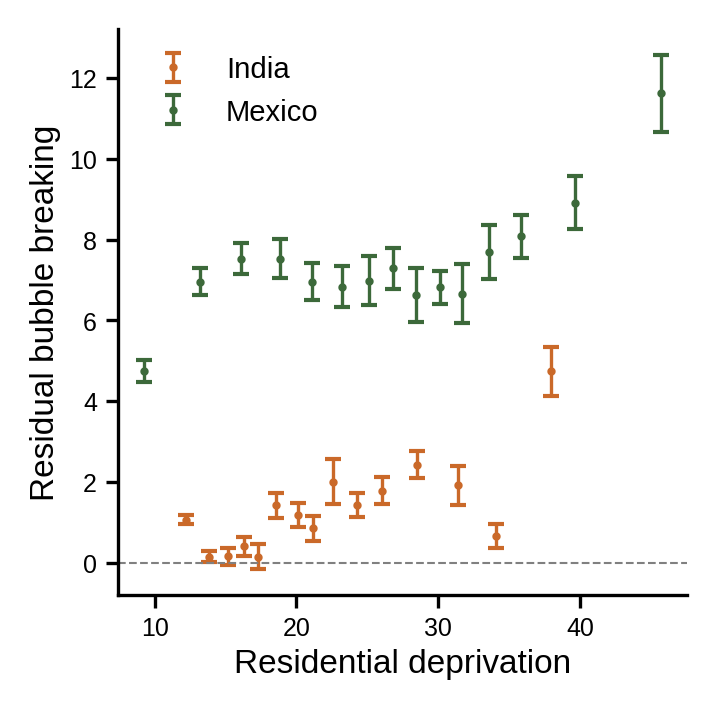

In [29]:
def bubble_breaking_gap_plot(data=None):
    threshold = "45 min"
    data_i = data[data['country']=='India'].copy()
    data_m = data[data['country']=='Mexico'].copy()
    fig = plt.figure(figsize=(60/24.5, 60/24.5),dpi = 300)
    ax = fig.add_subplot(1,1,1)
    # Calculate the error values
    yerr_india = [data_i["bbg_err"], data_i["bbg_err"]]
    yerr_mexico = [data_m["bbg_err"], data_m["bbg_err"]]
    offset = 0.25
    x_values_india = data_i["r"]
    x_values_mexico = data_m["r"]
    #########
    # Plot the error bars
    # Plot the first set of error bars (Residential)
    ax.errorbar(
        x_values_india - offset,  # Shift x-values left
        data_i["bbg_50"], 
        yerr=yerr_india, 
        fmt='o', 
        capsize=2, 
        label="India", 
        color='#ca6929',
        markersize=1
    )
    ax.errorbar(
        x_values_mexico - offset,  # Shift x-values left
        data_m["bbg_50"],
        yerr=yerr_mexico, 
        fmt='o', 
        capsize=2, 
        label="Mexico", 
        color='#3c693a',
        markersize=1
    )
    sns.despine(ax=ax)
    # Draw horizontal line at y=0
    ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')
    ax.set_xlabel("Residential deprivation")
    ax.set_ylabel("Residual bubble breaking")
    # ax.set_xlim([min(data['r']) - 5, max(data['r'] + 5)])
    # ax.set_ylim([min(data['bbe_50']) - 5, max(data['bbt_50']) + 5])
    ax.legend(loc='upper left', frameon=False)
    # ax.set_title(dict_country[countryID])
    fig.savefig(f"../figures/bbg_vs_r_{threshold}.pdf", dpi=600)


bubble_breaking_gap_plot(data=dfg_agg)

## 3. Bubble breaking gaps vs. travel time threshold (gravity model)

In [16]:
# Define custom palette
custom_palette = {
    'India': '#ca6929',
    'Mexico': '#3c693a',
    'india': '#ca6929',
    'mexico': '#3c693a'
}

def bbg_data_for_plot(df=None):
    # Step 1: Define a consistent threshold order from short to long
    threshold_order = ['10 min', '15 min', '20 min', '30 min', '45 min', '1 h', '2 h']

    # Step 2: Clean and prepare the DataFrame
    # Assume original df has: ['r', 'threshold', 'bbg_50', 'bbg_err']
    data = df[df['threshold'].isin(threshold_order)].copy()

    # Enforce categorical order on 'threshold' column
    data['threshold'] = pd.Categorical(data['threshold'], categories=threshold_order, ordered=True)

    # Step 3: Pivot the dataframe
    # We want to reshape so each threshold becomes a column for `bbg_50` and `bbg_err`
    bbg_50_wide = data.pivot(index='r', columns='threshold', values='bbg_50')
    bbg_err_wide = data.pivot(index='r', columns='threshold', values='bbg_err')

    # Rename columns to match desired naming convention
    bbg_50_wide.columns = [f'bbg_50_t{t.replace(" ", "")}' for t in bbg_50_wide.columns]
    bbg_err_wide.columns = [f'bbg_err_t{t.replace(" ", "")}' for t in bbg_err_wide.columns]

    # Step 4: Merge back together
    df_plot = pd.concat([bbg_50_wide, bbg_err_wide], axis=1)
    df_plot['r'] = df_plot.index
    df_plot.reset_index(drop=True, inplace=True)
    return df_plot

In [17]:
def bubble_breaking_gap_plot(df_b=None, countryID=None, 
                             thresholds=['10 min', '15 min', '20 min', '30 min', '45 min', '1 h', '2 h']):
    data = df_b.copy()
    fig, ax = plt.subplots(figsize=(3, 4), dpi=300)

    # Color palette
    # threshold_palette = sns.color_palette("Blues", n_colors=len(thresholds))
    threshold_palette = sns.light_palette(custom_palette[dict_country[countryID]], n_colors=len(thresholds))
    offset_step = 0.15
    base_x = data["r"]

    for i, thr in enumerate(thresholds):
        color = threshold_palette[i]
        offset = (i - len(thresholds) / 2) * offset_step
        thr_c = thr.replace(" ", "")
        y = data[f"bbg_50_t{thr_c}"]
        yerr = data[f"bbg_err_t{thr_c}"]

        # ax.errorbar(
        #     base_x + offset,
        #     y,
        #     yerr=[yerr, yerr],
        #     fmt='o',
        #     capsize=2,
        #     label=f'Threshold {thr}',
        #     color=color,
        #     markersize=1
        # )
        ax.plot(
            base_x,
            y,
            color=color,
            alpha=1,
            label=f'{thr}',
            linewidth=1
        )
    sns.despine(ax=ax)
    ax.axhline(y=0, color='gray', linewidth=0.5, linestyle='--')

    ax.set_xlabel("Deprivation")
    ax.set_ylabel("Bubble breaking gap")

    ax.set_xlim([min(data['r']) - 5, max(data['r']) + 5])
    ax.set_ylim([data.filter(like='bbg_50').min().min() - 5, data.filter(like='bbg_50').max().max() + 5])

    ax.legend(loc='lower left', bbox_to_anchor=(0, 0), frameon=False)

    fig.savefig(f"../figures/bbg_{dict_country[countryID]}.png", dpi=300, bbox_inches='tight')

In [ ]:
thresholds = ['10 min', '15 min', '20 min', '30 min', '1 h']    # '45 min', '2 h' have limited differences against 1 h
for countryID in ("in", "mx"): # "id", "co" are dropped due to lack of enough data
    print(dict_country[countryID])
    gdf_original = get_data(countryID=countryID)
    # Focus on cities
    gdf_original = gdf_original[gdf_original['cell'].isin(cells2keep)]
    gdf_original.rename(columns={'pre-covid': 'Empirical', 'pre-covid_cell': 'Residential', 'pre-covid_th': 'Theoretical'}, inplace=True)
    gdf_original.loc[:, 'bb_e'] = gdf_original.loc[:, 'Empirical'] - gdf_original.loc[:, 'Residential']
    gdf_original.loc[:, 'bb_t'] = gdf_original.loc[:, 'Theoretical'] - gdf_original.loc[:, 'Residential']
    gdf_original.loc[:, 'bb_g'] = gdf_original.loc[:, 'Empirical'] - gdf_original.loc[:, 'Theoretical']
    # Only focus on contrasting threshods' results
    gdf_original = gdf_original[gdf_original['threshold'].isin(thresholds)]
    df_b = bbg_data_for_plot(df=bubble_breaking_data(gdf=gdf_original, num_grp=30))
    bubble_breaking_gap_plot(df_b=df_b, countryID=countryID, thresholds=thresholds)

In [18]:
gdf_original.head()

,Empirical,Residential,cell,geometry,threshold,Theoretical,bb_e,bb_t,bb_g
0,12.674627,12.199861,8729a4c00ffffff,"POLYGON ((-116.8878 32.49408, -116.87985 32.50...",10 min,14.270461,-0.474766,-2.070601,1.595835
1,10.930065,11.939732,8729a4c01ffffff,"POLYGON ((-116.91195 32.50531, -116.904 32.517...",10 min,11.856368,1.009667,0.083364,0.926302
2,14.563558,12.934506,8729a4c02ffffff,"POLYGON ((-116.8638 32.50629, -116.85584 32.51...",10 min,16.138994,-1.629052,-3.204488,1.575437
3,13.171759,14.288293,8729a4c03ffffff,"POLYGON ((-116.88795 32.51753, -116.87999 32.5...",10 min,15.386663,1.116535,-1.098370,2.214904
4,11.975888,27.452765,8729a4c04ffffff,"POLYGON ((-116.88766 32.47063, -116.87971 32.4...",10 min,17.098110,15.476877,10.354655,5.122222


In [19]:
grouped_corr = gdf_original.groupby('threshold').apply(lambda g: g['bb_g'].corr(g['Residential'])).reset_index()
grouped_corr.rename(columns={0: 'Correlation'}, inplace=True)
grouped_corr['threshold'] = grouped_corr['threshold'].astype(str)
print(grouped_corr)

  threshold  Correlation
0       1 h     0.223277
1    10 min     0.519147
2    15 min     0.485854
3       2 h     0.223419
4    20 min     0.388877
5    30 min     0.227018
6    45 min     0.222654


/tmp/ipykernel_127032/3061463226.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped_corr = gdf_original.groupby('threshold').apply(lambda g: g['bb_g'].corr(g['Residential'])).reset_index()


## 4. Bubble breaking gaps in cities

In [20]:
# Columns to aggregate
agg_columns = ['Residential', 'Theoretical', 'Empirical', 'bb_e', 'bb_t', 'bb_g',
               'Number of POI', 'Number of Unique Categories', 'Entropy', 'Gini', 'POI density']
set_threshold = True

def city_agg(x):
    res = dict()
    for var in agg_columns:
        res[f"{var}_md"], res[f"{var}_md_err"] = bootstrap_median(x[var], n_bootstrap=1000)
    return pd.Series(res)


df_cities = []
df_raw = []
for countryID in ("in", "mx"): # "co" is dropped due to lack of enough data
    print(dict_country[countryID])
    gdf_original = get_data(countryID=countryID)
    # Load cell level population count
    file_path = "../data/population/population.json"
    # Load JSON as a Python dictionary
    with open(file_path, "r", encoding="utf-8") as f:
        pop_dict = json.load(f)

    # Focus on cities
    gdf_original = gdf_original[gdf_original['cell'].isin(cells2keep)]
    gdf_original = pd.merge(gdf_original, gdf[['cell', 'country', 'correct_name']], on = "cell", how = "left")
    gdf_original.rename(columns={'pre-covid': 'Empirical', 'pre-covid_cell': 'Residential', 'pre-covid_th': 'Theoretical'}, inplace=True)
    gdf_original.loc[:, 'bb_e'] = gdf_original.loc[:, 'Residential'] - gdf_original.loc[:, 'Empirical']
    gdf_original.loc[:, 'bb_t'] = gdf_original.loc[:, 'Residential'] - gdf_original.loc[:, 'Theoretical']
    gdf_original.loc[:, 'bb_g'] = gdf_original.loc[:, 'Theoretical'] - gdf_original.loc[:, 'Empirical']

    if set_threshold:
        # Only focus on 30 min threshold
        gdf_original = gdf_original[gdf_original['threshold']=='45 min']

    gdf_original.loc[:, 'pop'] = gdf_original.loc[:, 'cell'].map(pop_dict)
    gdf_original.dropna(inplace=True)

    # Load duration data
    gdf_original = pd.merge(gdf_original, get_weekly_data(countryID=countryID), on = "cell", how = "left")

    # Load POI data
    df_poi = pd.read_csv(f"../data/pois/pois_{dict_country[countryID]}_cell.csv"
                        , usecols=['cell', 'Number of POI', 'Number of Unique Categories', 'Entropy', 'Gini'])
    gdf_original = pd.merge(gdf_original, df_poi, on = "cell", how = "left")
    gdf_original.loc[:, 'POI density'] = gdf_original.loc[:, 'Number of POI'] / gdf_original.loc[:, 'pop']  # POI density

    df_raw.append(gdf_original.drop(columns=['geometry']))
    # Group and aggregate
    agg_df = gdf_original.groupby('correct_name')[agg_columns].apply(city_agg).reset_index()

    # Flatten column names
    # agg_df.columns = ['_'.join(col).strip('_') for col in agg_df.columns.values]
    agg_df.loc[:, 'country'] = dict_country[countryID].capitalize()
    df_cities.append(agg_df)
df_cities = pd.concat(df_cities, ignore_index=True)
df_raw = pd.concat(df_raw, ignore_index=True)
df_raw.rename(columns={'country': 'Country'}, inplace=True)
ds = []
countries = ["mexico","india"]
for countryname in countries:
    tmp_df_detour = pd.read_csv("../data/detour/"+countryname+".csv",sep = ",")
    ds.append(tmp_df_detour)
df_detour = pd.concat(ds)
df_raw = pd.merge(df_detour, df_raw, on='cell', how='left')

india
mexico


In [21]:
df_cities = pd.merge(df_cities, gdf_info[['correct_name', 'pop_density']], on = ["correct_name"], how = "left")
df_cities.rename(columns={'country': 'Country'}, inplace=True)
df_cities.head()

,correct_name,Residential_md,Residential_md_err,Theoretical_md,Theoretical_md_err,Empirical_md,Empirical_md_err,bb_e_md,bb_e_md_err,bb_t_md,...,Number of Unique Categories_md,Number of Unique Categories_md_err,Entropy_md,Entropy_md_err,Gini_md,Gini_md_err,POI density_md,POI density_md_err,Country,pop_density
0,Ahmadabad,19.319323,0.813995,19.899551,0.477504,18.659629,0.181728,0.659693,0.359822,-0.580228,...,15.320988,1.048380,3.378331,0.073491,0.864997,0.005902,0.001177,0.000104,India,11916.459803
1,Bangalore,24.009226,1.589994,24.151098,0.533082,25.254750,0.955393,-1.245524,0.644549,-0.141872,...,14.264151,1.051760,3.282009,0.084485,0.855287,0.003846,0.000905,0.000056,India,10484.785021
2,Bhopal,28.939407,0.997521,29.442692,1.054668,26.867231,0.653864,2.072176,1.330208,-0.503286,...,10.674419,1.444202,2.871542,0.212834,0.798310,0.018253,0.000575,0.000076,India,8302.054387
3,Bhubaneswar,27.012611,1.556198,29.605674,0.285781,25.970628,0.437295,1.041983,0.922978,-2.593063,...,13.928571,1.541702,3.399910,0.177563,0.880065,0.012291,0.000982,0.000177,India,6275.345325
4,Chandigarh,19.914288,0.748894,21.742959,0.696593,18.164521,0.465609,1.749767,0.690109,-1.828671,...,14.596154,1.287540,3.205964,0.106200,0.872874,0.006374,0.001583,0.000255,India,7473.381372


In [10]:
df_raw[df_raw['threshold'] == '45 min'].to_csv("../data/cell_statistics_45_min.csv", index=False)

### Residual bubble breaking vs. time threshold (Gravity model)

In [22]:
df_raw.groupby('Country')['wm_duration_min'].median()

Country
india     69.575926
mexico    60.911826
Name: wm_duration_min, dtype: float64

In [24]:
def threshold_agg(x):
    res = dict()
    var = 'bb_e'
    res[f"{var}_md"], res[f"{var}_md_err"] = bootstrap_median(x[var], n_bootstrap=1000)
    return pd.Series(res)

group_num = 10
var = 'bb_e'
df_raw2plot = df_raw.loc[df_raw['threshold'] == '45 min', ['correct_name', var, 'Country', 'wm_duration_min']].copy()
df_raw2plot["wm_duration_min_grp"] = (
    df_raw2plot.groupby("Country")["wm_duration_min"]
    .transform(lambda x: pd.qcut(x, q=group_num, labels=range(1, group_num + 1)))
)
df_raw2plot = df_raw2plot.groupby(['Country', 'wm_duration_min_grp'], observed=True).apply(threshold_agg).reset_index()
df_raw2plot['wm_duration_min_grp'] = df_raw2plot['wm_duration_min_grp'].astype(int)

/tmp/ipykernel_51575/339372680.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_raw2plot = df_raw2plot.groupby(['Country', 'wm_duration_min_grp'], observed=True).apply(threshold_agg).reset_index()


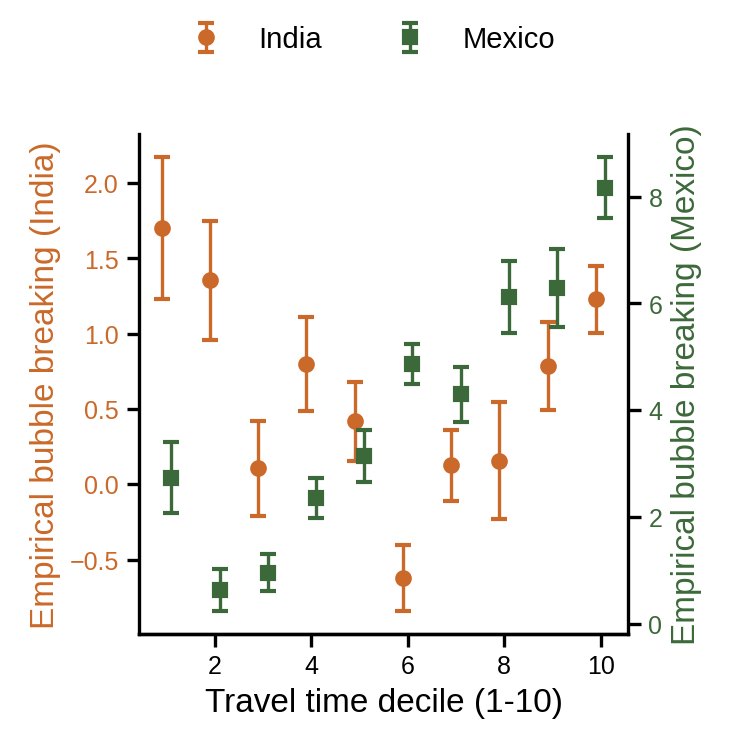

✅ Figure saved to: ../figures/bbe_vs_wm_duration_min_grp.pdf


In [25]:
title, x_label, var = 'Travel time', 'Travel time decile (1-10)', 'wm_duration_min_grp'
var_y = 'bb_e'

# --- Split by country ---
data_i = df_raw2plot[df_raw2plot['Country'].str.lower() == 'india'].copy()
data_m = df_raw2plot[df_raw2plot['Country'].str.lower() == 'mexico'].copy()

# --- Build figure ---
fig, ax1 = plt.subplots(figsize=(60/24.5, 60/24.5), dpi=300)

# ------------------------------------------------------------
# Plot India
# ------------------------------------------------------------
line1 = ax1.errorbar(
    data_i[var] - 0.1,
    data_i[f"{var_y}_md"],
    yerr=[data_i[f"{var_y}_md_err"], data_i[f"{var_y}_md_err"]],
    fmt='o', color='#ca6929', capsize=2, markersize=3, label="India"
)

ax1.set_ylabel("Empirical bubble breaking (India)", color='#ca6929')
ax1.tick_params(axis='y', labelcolor='#ca6929')
ax1.set_xlabel(x_label)
# ------------------------------------------------------------
# Plot Mexico (right axis)
# ------------------------------------------------------------
ax2 = ax1.twinx()

line2 = ax2.errorbar(
    data_m[var] + 0.1,
    data_m[f"{var_y}_md"],
    yerr=[data_m[f"{var_y}_md_err"], data_m[f"{var_y}_md_err"]],
    fmt='s', color='#3c693a', capsize=2, markersize=3, label="Mexico"
)

ax2.set_ylabel("Empirical bubble breaking (Mexico)", color='#3c693a')
ax2.tick_params(axis='y', labelcolor='#3c693a')

sns.despine(ax=ax1, right=False)
sns.despine(ax=ax2, left=True)

# ------------------------------------------------------------
# Legend (combine both axes)
# ------------------------------------------------------------
lines = [line1, line2]
labels = ["India", "Mexico"]
fig.legend(lines, labels, loc="upper center", ncol=2, frameon=False)

plt.tight_layout(rect=[0, 0, 1, 0.88])

# Save
save_path = f"../figures/bbe_vs_{var}.pdf"
fig.savefig(save_path, dpi=600)
plt.show()

print(f"✅ Figure saved to: {save_path}")

In [46]:
def threshold_agg(x):
    res = dict()
    var = 'Theoretical'
    res[f"{var}_md"], res[f"{var}_md_err"] = bootstrap_median(x[var], n_bootstrap=1000)
    return pd.Series(res)

var = 'Theoretical'
df_threshold = df_raw.groupby(['threshold', 'Country'])[[var]].apply(threshold_agg).reset_index()
order = ["10 min", "15 min", "20 min", "30 min", "45 min", "1 h", "2 h"]
df_threshold["threshold"] = pd.Categorical(
    df_threshold["threshold"],
    categories=order,
    ordered=True
)
df_threshold

,threshold,Country,Theoretical_md,Theoretical_md_err
0,1 h,india,23.762309,0.208869
1,1 h,mexico,30.376100,0.225076
2,10 min,india,22.481091,0.205365
3,10 min,mexico,27.739115,0.191793
4,15 min,india,23.356150,0.206151
5,15 min,mexico,28.541283,0.182699
6,2 h,india,23.767595,0.198966
7,2 h,mexico,30.376731,0.234657
8,20 min,india,23.685202,0.232425
9,20 min,mexico,29.116919,0.151412


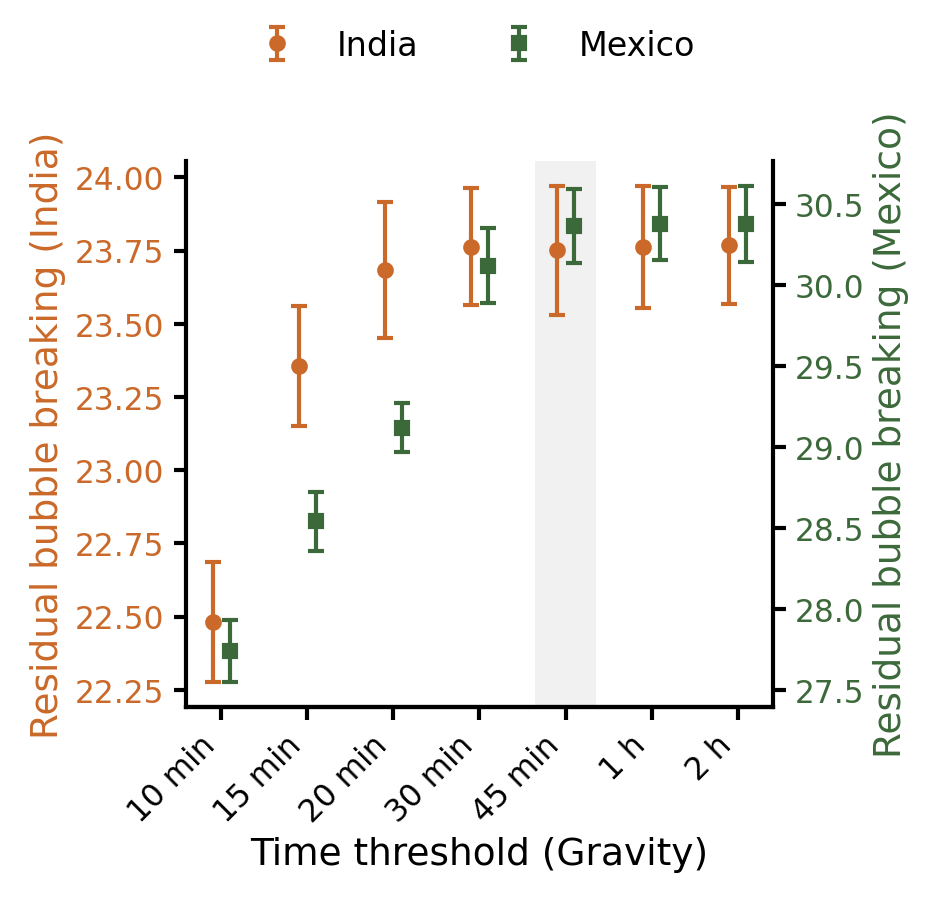

✅ Figure saved to: ../figures/bbt_vs_threshold.png


In [47]:
title, x_label, var = 'Travel time threshold in Gravity model', 'Time threshold (Gravity)', 'threshold'
var_y = 'Theoretical'

# --- Split by country ---
data_i = df_threshold[df_threshold['Country'].str.lower() == 'india'].copy()
data_m = df_threshold[df_threshold['Country'].str.lower() == 'mexico'].copy()

# Define desired ordering
threshold_order = ["10 min", "15 min", "20 min", "30 min", "45 min", "1 h", "2 h"]

# Convert threshold columns
df_threshold["threshold"] = df_threshold["threshold"].astype(str)

for d in [data_i, data_m]:
    d["threshold"] = pd.Categorical(
        d["threshold"],
        categories=threshold_order,
        ordered=True
    )
    d["threshold_num"] = d["threshold"].cat.codes   # 0,1,2,...

# --- Build figure ---
fig, ax1 = plt.subplots(figsize=(3.2, 3), dpi=300)

# ------------------------------------------------------------
# Highlight area around "30 min"
# ------------------------------------------------------------
highlight_label = "45 min"
highlight_center = threshold_order.index(highlight_label)
ax1.axvspan(highlight_center - 0.35, highlight_center + 0.35,
            color=None, alpha=0.3, zorder=0, facecolor='lightgray')

# ------------------------------------------------------------
# Plot India
# ------------------------------------------------------------
line1 = ax1.errorbar(
    data_i["threshold_num"] - 0.1,
    data_i[f"{var_y}_md"],
    yerr=[data_i[f"{var_y}_md_err"], data_i[f"{var_y}_md_err"]],
    fmt='o', color='#ca6929', capsize=2, markersize=3, label="India"
)

ax1.set_ylabel("Residual bubble breaking (India)", color='#ca6929')
ax1.tick_params(axis='y', labelcolor='#ca6929')

# ------------------------------------------------------------
# Plot Mexico (right axis)
# ------------------------------------------------------------
ax2 = ax1.twinx()

line2 = ax2.errorbar(
    data_m["threshold_num"] + 0.1,
    data_m[f"{var_y}_md"],
    yerr=[data_m[f"{var_y}_md_err"], data_m[f"{var_y}_md_err"]],
    fmt='s', color='#3c693a', capsize=2, markersize=3, label="Mexico"
)

ax2.set_ylabel("Residual bubble breaking (Mexico)", color='#3c693a')
ax2.tick_params(axis='y', labelcolor='#3c693a')

# ------------------------------------------------------------
# Shared x-axis labeling
# ------------------------------------------------------------
ax1.set_xticks(range(len(threshold_order)))
ax1.set_xticklabels(threshold_order, rotation=45, ha='right')
ax1.set_xlabel(x_label)

sns.despine(ax=ax1, right=False)
sns.despine(ax=ax2, left=True)

# ------------------------------------------------------------
# Legend (combine both axes)
# ------------------------------------------------------------
lines = [line1, line2]
labels = ["India", "Mexico"]
fig.legend(lines, labels, loc="upper center", ncol=2, frameon=False, fontsize=8)

plt.tight_layout(rect=[0, 0, 1, 0.88])

# Save
save_path = f"../figures/bbt_vs_{var}.png"
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Figure saved to: {save_path}")

### 4.1 BBG vs. POI entropy

In [75]:
from scipy.stats import spearmanr

results = []

for country in ["mexico", "india"]:
    df_c = df_raw[df_raw["Country"].str.lower() == country.lower()].copy()
    
    # Drop NaN values for the two variables
    valid = df_c[["bb_g", "Entropy"]].dropna()
    
    # Compute Spearman correlation
    corr, pval = spearmanr(valid["bb_g"], valid["Entropy"])
    
    results.append({
        "Country": country.title(),
        "Spearman_rho": corr,
        "p_value": pval,
        "n_obs": len(valid)
    })

# Convert to DataFrame for a nice summary
print("POI entropy")
results_df = pd.DataFrame(results)
print(results_df)

POI entropy
  Country  Spearman_rho       p_value  n_obs
0  Mexico     -0.233780  1.269535e-33   2601
1   India     -0.147596  5.339334e-11   1957


In [76]:
results = []

for country in ["mexico", "india"]:
    df_c = df_raw[df_raw["Country"].str.lower() == country.lower()].copy()
    
    # Drop NaN values for the two variables
    valid = df_c[["bb_g", "POI density"]].dropna()
    
    # Compute Spearman correlation
    corr, pval = spearmanr(valid["bb_g"], valid["POI density"])
    
    results.append({
        "Country": country.title(),
        "Spearman_rho": corr,
        "p_value": pval,
        "n_obs": len(valid)
    })

# Convert to DataFrame for a nice summary
print("POI density")
results_df = pd.DataFrame(results)
print(results_df)

POI density
  Country  Spearman_rho       p_value  n_obs
0  Mexico     -0.168529  5.099430e-18   2600
1   India      0.007047  7.553855e-01   1957


In [77]:
results = []

for country in ["mexico", "india"]:
    df_c = df_raw[df_raw["Country"].str.lower() == country.lower()].copy()
    
    # Drop NaN values for the two variables
    valid = df_c[["bb_g", "detour"]].dropna()
    
    # Compute Spearman correlation
    corr, pval = spearmanr(valid["bb_g"], valid["detour"])
    
    results.append({
        "Country": country.title(),
        "Spearman_rho": corr,
        "p_value": pval,
        "n_obs": len(valid)
    })

# Convert to DataFrame for a nice summary
print("Detour index")
results_df = pd.DataFrame(results)
print(results_df)

Detour index
  Country  Spearman_rho       p_value  n_obs
0  Mexico      0.175067  2.391284e-19   2601
1   India      0.024181  2.849787e-01   1957


In [78]:
results = []

for country in ["mexico", "india"]:
    df_c = df_raw[df_raw["Country"].str.lower() == country.lower()].copy()
    
    # Drop NaN values for the two variables
    valid = df_c[["bb_g", "wm_duration_min"]].dropna()
    
    # Compute Spearman correlation
    corr, pval = spearmanr(valid["bb_g"], valid["wm_duration_min"])
    
    results.append({
        "Country": country.title(),
        "Spearman_rho": corr,
        "p_value": pval,
        "n_obs": len(valid)
    })

# Convert to DataFrame for a nice summary
print("Trip duration")
results_df = pd.DataFrame(results)
print(results_df)

Trip duration
  Country  Spearman_rho       p_value  n_obs
0  Mexico      0.150595  1.156818e-14   2601
1   India      0.036766  1.039600e-01   1957


In [79]:
import pandas as pd
from scipy import stats

# Variables of interest
vars_explanatory = ['Entropy', 'POI density', 'Residential', 'detour', 'wm_duration_min']
target_var = 'bb_g'

# Initialize list to collect results
results = []

# Loop over countries and variables
for country, df_sub in df_raw.groupby('Country'):
    for var in vars_explanatory + [target_var]:
        # Compute basic statistics
        median = df_sub[var].median()
        p5 = df_sub[var].quantile(0.05)
        p95 = df_sub[var].quantile(0.95)

        # Compute Spearman correlation (skip for bb_g itself)
        if var != target_var:
            rho, pval = stats.spearmanr(df_sub[var], df_sub[target_var], nan_policy='omit')
        else:
            rho, pval = None, None

        results.append({
            'Country': country,
            'Variable': var,
            'Median': median,
            'P5': p5,
            'P95': p95,
            'Spearman_rho': rho,
            'p_value': pval
        })

# Create DataFrame
df_summary = pd.DataFrame(results)

# Round for presentation
df_summary = df_summary.round({
    'Median': 3, 'P5': 3, 'P95': 3, 'Spearman_rho': 3
})
df_summary['p_value'] = df_summary['p_value'].apply(lambda x: f"{x:.3g}" if pd.notnull(x) else None)

# Reorder columns
df_summary = df_summary[['Country', 'Variable', 'Median', 'P5', 'P95', 'Spearman_rho', 'p_value']]

# Display
print(df_summary)

   Country         Variable  Median      P5      P95  Spearman_rho   p_value
0    india          Entropy   3.471   1.578    4.055        -0.148  5.34e-11
1    india      POI density   0.001   0.000    0.004         0.007     0.755
2    india      Residential  21.399  12.856   37.003         0.153  1.08e-11
3    india           detour   1.695   1.018    3.739         0.024     0.285
4    india  wm_duration_min  69.576  50.269  103.238         0.037     0.104
5    india             bb_g   0.909  -4.890    8.836           NaN      None
6   mexico          Entropy   3.240   0.000    4.022        -0.234  1.27e-33
7   mexico      POI density   0.001   0.000    0.005        -0.169   5.1e-18
8   mexico      Residential  27.037  10.618   43.508         0.150   1.6e-14
9   mexico           detour   1.373   1.244    1.706         0.175  2.39e-19
10  mexico  wm_duration_min  60.912  41.943   80.206         0.151  1.16e-14
11  mexico             bb_g   6.997  -0.269   16.949           NaN      None

<Axes: >

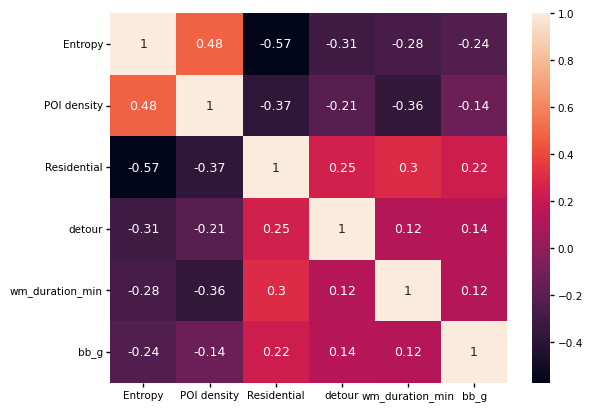

In [80]:
sns.heatmap(df_raw.loc[df_raw['Country'] == 'mexico', ['Entropy', 'POI density', 'Residential', 'detour', 'wm_duration_min', 'bb_g']].corr(), annot=True)

<Axes: >

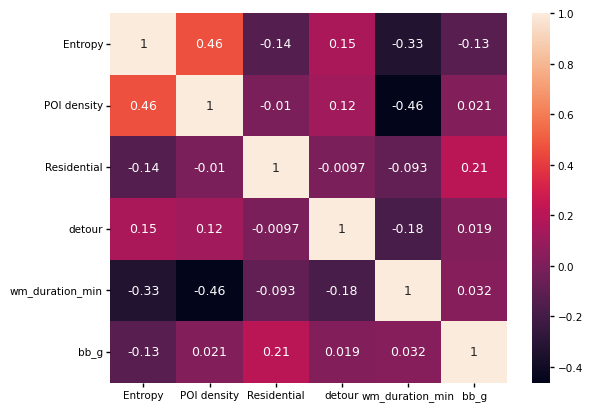

In [81]:
sns.heatmap(df_raw.loc[df_raw['Country'] == 'india', ['Entropy', 'POI density', 'Residential', 'detour', 'wm_duration_min', 'bb_g']].corr(), annot=True)

In [83]:
def bubble_breaking_gap_plot(data=None, var=None, x_label=None, title=None):
    """
    Plot residual bubble-breaking gaps for India and Mexico side by side,
    with an overall figure title.
    """
    threshold = "30 min"

    # --- Split by country ---
    data_i = data[data['Country'].str.lower() == 'india'].copy()
    data_m = data[data['Country'].str.lower() == 'mexico'].copy()

    # --- Create 1×2 subplot ---
    fig, axes = plt.subplots(1, 2, figsize=(16/3, 16/6), dpi=300, sharey=False)
    countries = [
        ("India", data_i, '#ca6929', (-1, 6)),
        ("Mexico", data_m, '#3c693a', (4, 13))
    ]

    # --- Loop over the two countries ---
    for ax, (name, df, color, y_lim) in zip(axes, countries):
        yerr = [df["bbg_err"], df["bbg_err"]]
        x_values = df["r"]

        ax.errorbar(
            x_values,
            df["bbg_50"],
            yerr=yerr,
            fmt='o',
            capsize=2,
            color=color,
            markersize=2,
            alpha=0.8,
        )

        ax.set_title(name, loc='left', fontweight='bold')
        ax.set_xlabel(x_label)
        sns.despine(ax=ax)
        ax.grid(False)

    # Shared y-label
    axes[0].set_ylabel("Residual bubble breaking")
    axes[1].set_ylabel("")

    # --- Overall Title ---
    if title is None:
        title = f"Residual Bubble-Breaking Gap vs. {x_label}"

    fig.suptitle(title, fontsize=12, fontweight='bold', y=0.9)

    # Adjust layout so title is clearly above
    plt.tight_layout(rect=[0, 0, 1, 0.95])

    save_path = f"../figures/bbg_vs_{var}_{threshold}.png"
    fig.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"✅ Figure saved to: {save_path}")

    plt.show()

/tmp/ipykernel_14022/400321453.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return dfg.groupby('Country', group_keys=False, observed=True).apply(assign_bins)


✅ Figure saved to: ../figures/bbg_vs_Entropy_30 min.png


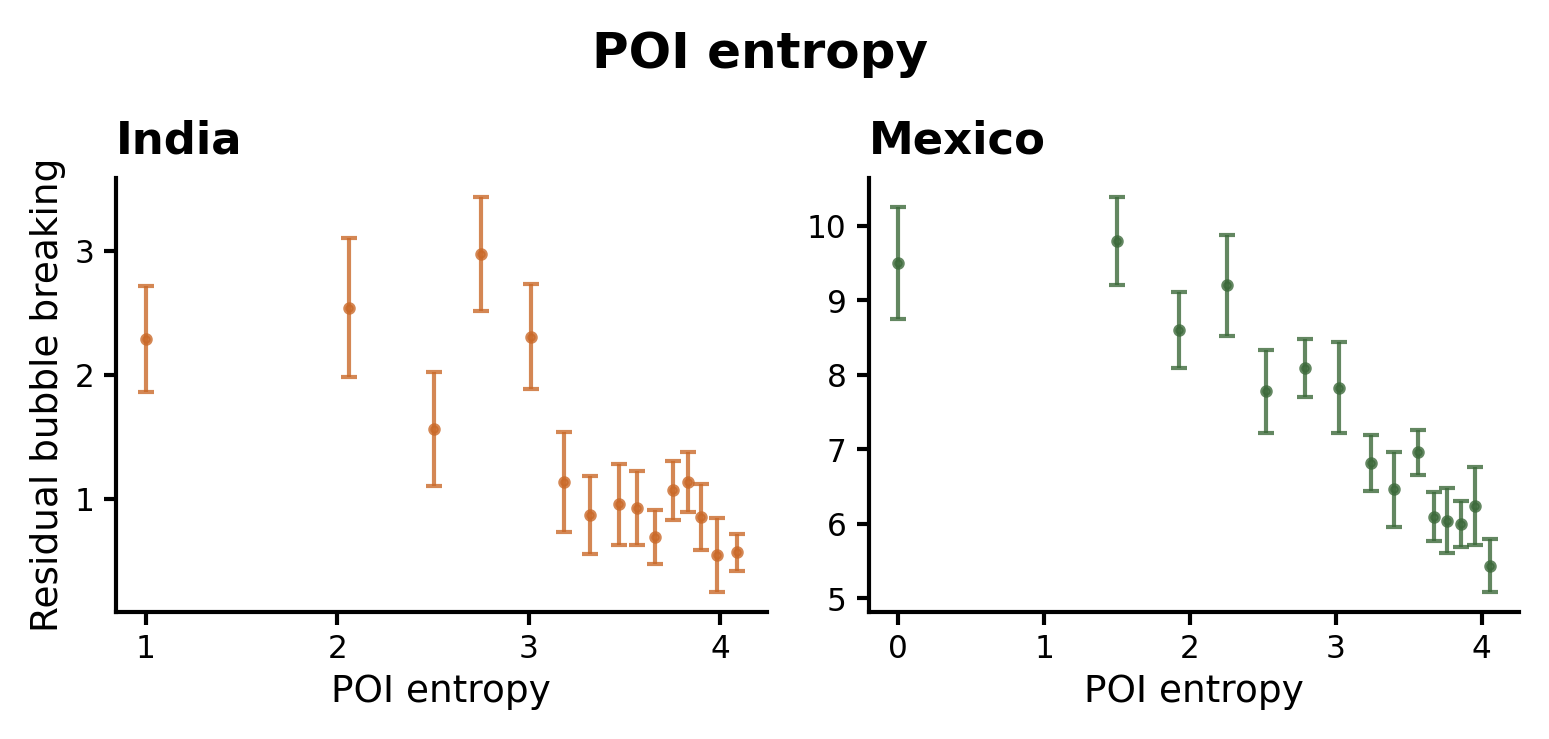

In [84]:
bubble_breaking_gap_plot(data=bubble_breaking_gap_contrast_data(dfg=df_raw, num_grp=15, x_var="Entropy"), var="Entropy", x_label='POI entropy', title='POI entropy')

### 4.2 BBG vs. POI density

/tmp/ipykernel_14022/400321453.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return dfg.groupby('Country', group_keys=False, observed=True).apply(assign_bins)


✅ Figure saved to: ../figures/bbg_vs_POI density_30 min.png


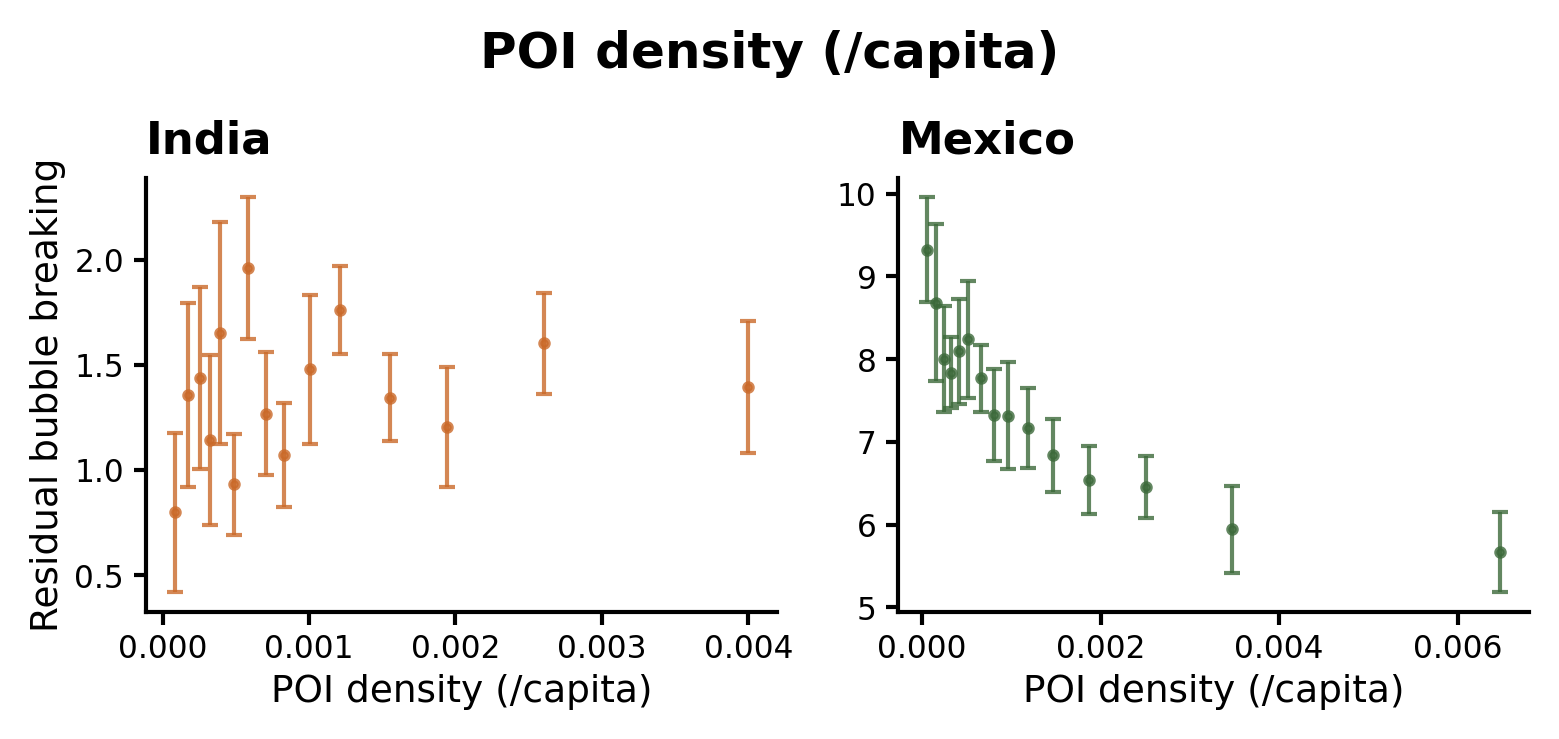

In [85]:
bubble_breaking_gap_plot(data=bubble_breaking_gap_contrast_data(dfg=df_raw, num_grp=15, x_var="POI density"), var="POI density", x_label='POI density (/capita)', title='POI density (/capita)')

In [ ]:
# Plot the scatter chart - POI entropy vs Bubble breaking gap
city_scatter_chart(df_cities=df_cities, df_raw=df_raw, x_var='Entropy_md', x_var_raw='Entropy', 
                   x_lb="POI Entropy", file_end='poi_entropy', xlm=(1.6, 4.2), ylm=(-5, 25), 
                   errorbar_display=False, legend_show=False)

### 4.3 BBG vs. POI density + entropy

In [10]:
df_raw['log_POI_density'] = np.log(df_raw['POI density'] + 1e-6)
df_raw.iloc[0]

cell                               874995b86ffffff
detour                                    1.210166
Empirical                                  9.94913
Residential                              12.554252
threshold                                   45 min
Theoretical                              11.706087
Country                                     mexico
correct_name                   Greater Mexico City
bb_e                                      2.605122
bb_t                                      0.848165
bb_g                                      1.756957
pop                                   86480.771429
wm_duration_min                          45.253772
wm_length_m                               0.365647
Number of POI                                390.0
Number of Unique Categories                   26.0
Entropy                                   3.693287
Gini                                      0.875411
POI density                                0.00451
log_POI_density                

In [11]:
countries = ['india', 'mexico']

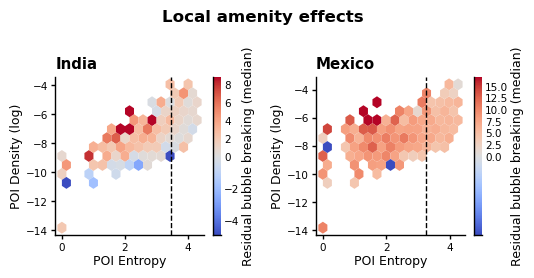

In [12]:
def _get_norm(vmin, vmax):
    """
    Flexible color normalization:
    - If vmin < 0 < vmax → TwoSlopeNorm centered at 0
    - If both vmin and vmax > 0 → LogNorm
    - Else → simple linear Normalize
    """
    # Case 1: Values span both sides of zero → diverging
    if vmin < 0 < vmax:
        return mpl.colors.TwoSlopeNorm(vmin=vmin, vcenter=0, vmax=vmax)

    # Case 2: All positive → log scale recommended
    if vmin > 0:
        return mpl.colors.LogNorm(vmin=vmin, vmax=vmax)

    # Case 3: All negative → log on magnitude
    if vmax < 0:
        return mpl.colors.LogNorm(vmin=abs(vmax), vmax=abs(vmin))

    # Fallback: linear
    return mpl.colors.Normalize(vmin=vmin, vmax=vmax)


fig, axes = plt.subplots(1, 2, figsize=(16/3, 16/6), sharex=False, sharey=False)

for ax, country in zip(axes, countries):

    df2plot = df_raw[df_raw["Country"] == country].copy()

    values = df2plot["bb_g"]

    # Robust color range (5–95th percentile)
    vmin, vmax = values.quantile([0.05, 0.95])

    # Use your smart normalization
    norm = _get_norm(vmin, vmax)

    hb = ax.hexbin(
        df2plot["Entropy"],
        df2plot["log_POI_density"],
        C=values,
        gridsize=15,
        cmap="coolwarm",
        reduce_C_function=np.median,
        norm=norm,
        mincnt=1,
        edgecolors='none',
        linewidths=0,
    )

    # ---------- ✅ ADD MEDIAN ENTROPY LINE ----------
    entropy_median = df2plot["Entropy"].median()
    ax.axvline(
        entropy_median,
        color="black",
        linestyle="--",
        linewidth=1
    )
    # ------------------------------------------------

    ax.set_title(country.capitalize(), loc='left', fontweight='bold')
    ax.set_xlabel("POI Entropy")
    ax.set_ylabel("POI Density (log)")

    # ---- CLEAN COLORBAR ----
    cbar = fig.colorbar(hb, ax=ax)
    cbar.outline.set_visible(False)
    for sp in cbar.ax.spines.values():
        sp.set_visible(False)
    cbar.ax.tick_params(length=0)
    cbar.set_label("Residual bubble breaking (median)")

sns.despine()
fig.suptitle("Local amenity effects", fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()

plt.savefig("../figures/bbg_vs_POI_with_norm.png", dpi=300, bbox_inches="tight")
plt.show()

## 5. Trip duration (min)

In [91]:
for countryID in ("in", "mx"): # "id", "co" are dropped due to lack of enough data
    print(dict_country[countryID])
    r_values = df_raw[(df_raw['Country'] == dict_country[countryID])]['wm_duration_min'].dropna()
    bb_g_values2test = df_raw[(df_raw['Country'] == dict_country[countryID])]['bb_g'].dropna()
    print(f"Spearman correlation: {spearmanr(bb_g_values2test, r_values).correlation:.3f}, p-value: {spearmanr(bb_g_values2test, r_values).pvalue:.3e}")

india
Spearman correlation: 0.037, p-value: 1.040e-01
mexico
Spearman correlation: 0.151, p-value: 1.157e-14


/tmp/ipykernel_14022/400321453.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return dfg.groupby('Country', group_keys=False, observed=True).apply(assign_bins)


✅ Figure saved to: ../figures/bbg_vs_wm_duration_min_30 min.png


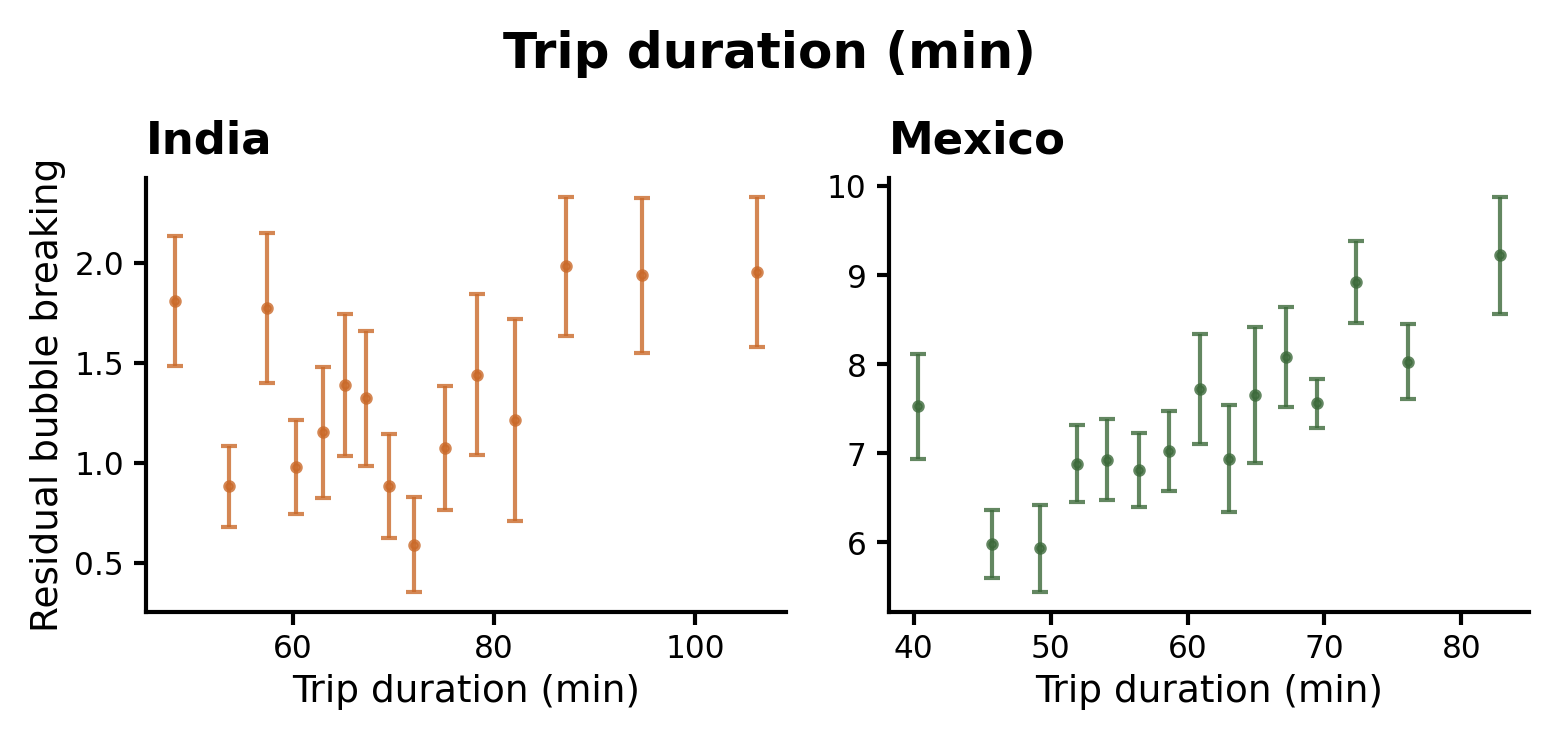

In [92]:
bubble_breaking_gap_plot(data=bubble_breaking_gap_contrast_data(dfg=df_raw, num_grp=15, x_var="wm_duration_min"), var="wm_duration_min", x_label='Trip duration (min)', title='Trip duration (min)')

## 6. Detour index

In [99]:
# Spearman correlation between detour and bb_e
for c in ['india', 'mexico']:
    print(c)
    print('Overall')
    r_values = df_raw[(df_raw['threshold'] == '45 min') & (df_raw['Country'] == c)]['detour'].dropna()
    bb_e_values2test = df_raw[(df_raw['threshold'] == '45 min') & (df_raw['Country'] == c)]['bb_g'].dropna()
    print(f"Spearman correlation: {spearmanr(bb_e_values2test, r_values).correlation:.3f}, p-value: {spearmanr(bb_e_values2test, r_values).pvalue:.3e}")
    print('Detour > 1.5')
    r_values = df_raw[(df_raw['threshold'] == '30 min') & (df_raw['Country'] == c) & (df_raw['detour'] > 1.5)]['detour'].dropna()
    bb_e_values2test = df_raw[(df_raw['threshold'] == '30 min') & (df_raw['Country'] == c) & (df_raw['detour'] > 1.5)]['bb_g'].dropna()
    print(f"Spearman correlation: {spearmanr(bb_e_values2test, r_values).correlation:.3f}, p-value: {spearmanr(bb_e_values2test, r_values).pvalue:.3e}")
    print('Detour < 1.5')
    r_values = df_raw[(df_raw['threshold'] == '30 min') & (df_raw['Country'] == c) & (df_raw['detour'] < 1.5)]['detour'].dropna()
    bb_e_values2test = df_raw[(df_raw['threshold'] == '30 min') & (df_raw['Country'] == c) & (df_raw['detour'] < 1.5)]['bb_g'].dropna()
    print(f"Spearman correlation: {spearmanr(bb_e_values2test, r_values).correlation:.3f}, p-value: {spearmanr(bb_e_values2test, r_values).pvalue:.3e}")
    print("\n")

india
Overall
Spearman correlation: 0.024, p-value: 2.850e-01
Detour > 1.5
Spearman correlation: nan, p-value: nan
Detour < 1.5
Spearman correlation: nan, p-value: nan


mexico
Overall
Spearman correlation: 0.175, p-value: 2.391e-19
Detour > 1.5
Spearman correlation: nan, p-value: nan
Detour < 1.5
Spearman correlation: nan, p-value: nan




/tmp/ipykernel_14022/400321453.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return dfg.groupby('Country', group_keys=False, observed=True).apply(assign_bins)


✅ Figure saved to: ../figures/bbg_vs_detour_30 min.png


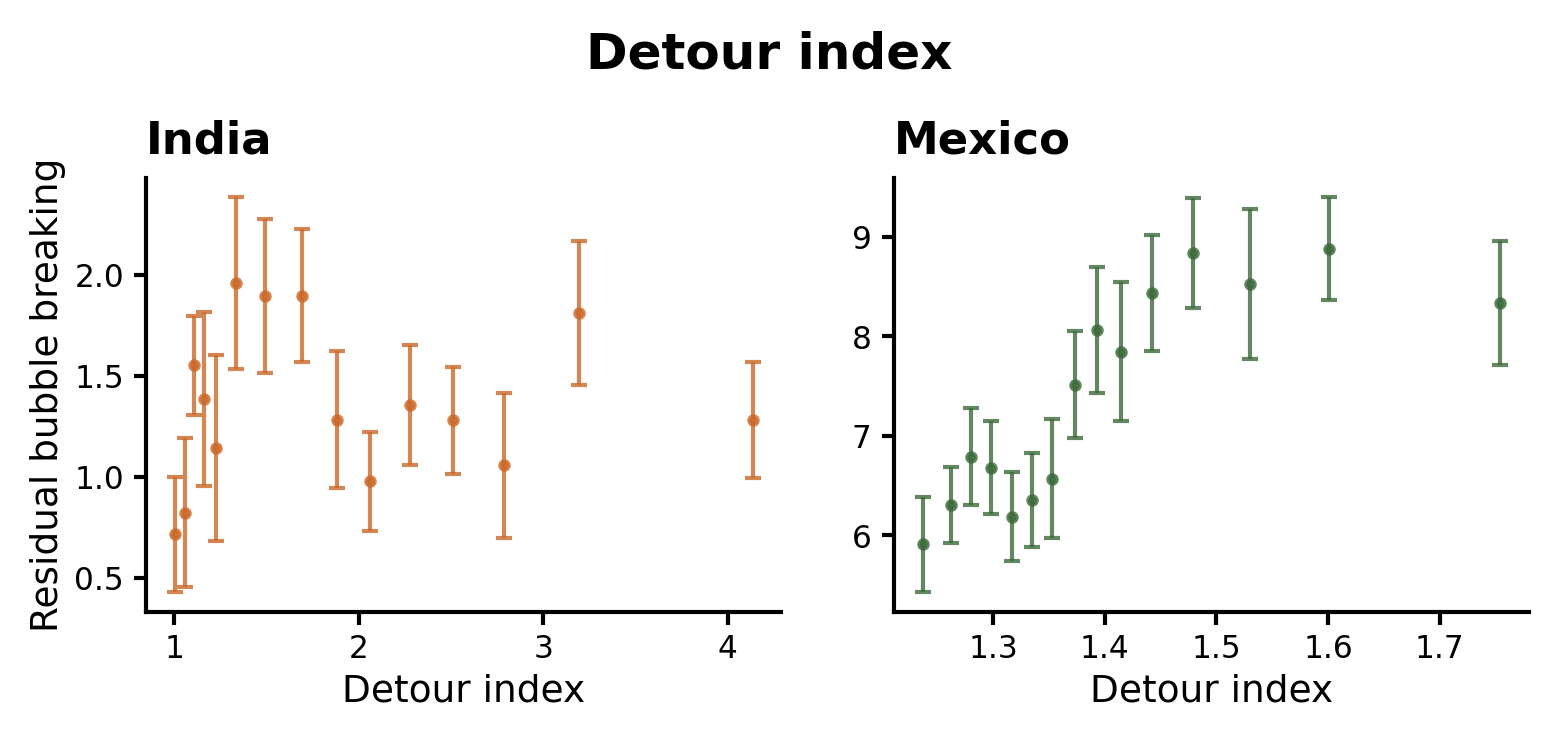

In [100]:
bubble_breaking_gap_plot(data=bubble_breaking_gap_contrast_data(dfg=df_raw, num_grp=15, x_var="detour"), var="detour", x_label='Detour index', title='Detour index')

/tmp/ipykernel_747177/400321453.py:13: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  return dfg.groupby('Country', group_keys=False, observed=True).apply(assign_bins)


✅ Figure saved to: ../figures/bbg_vs_detour_30 min.png


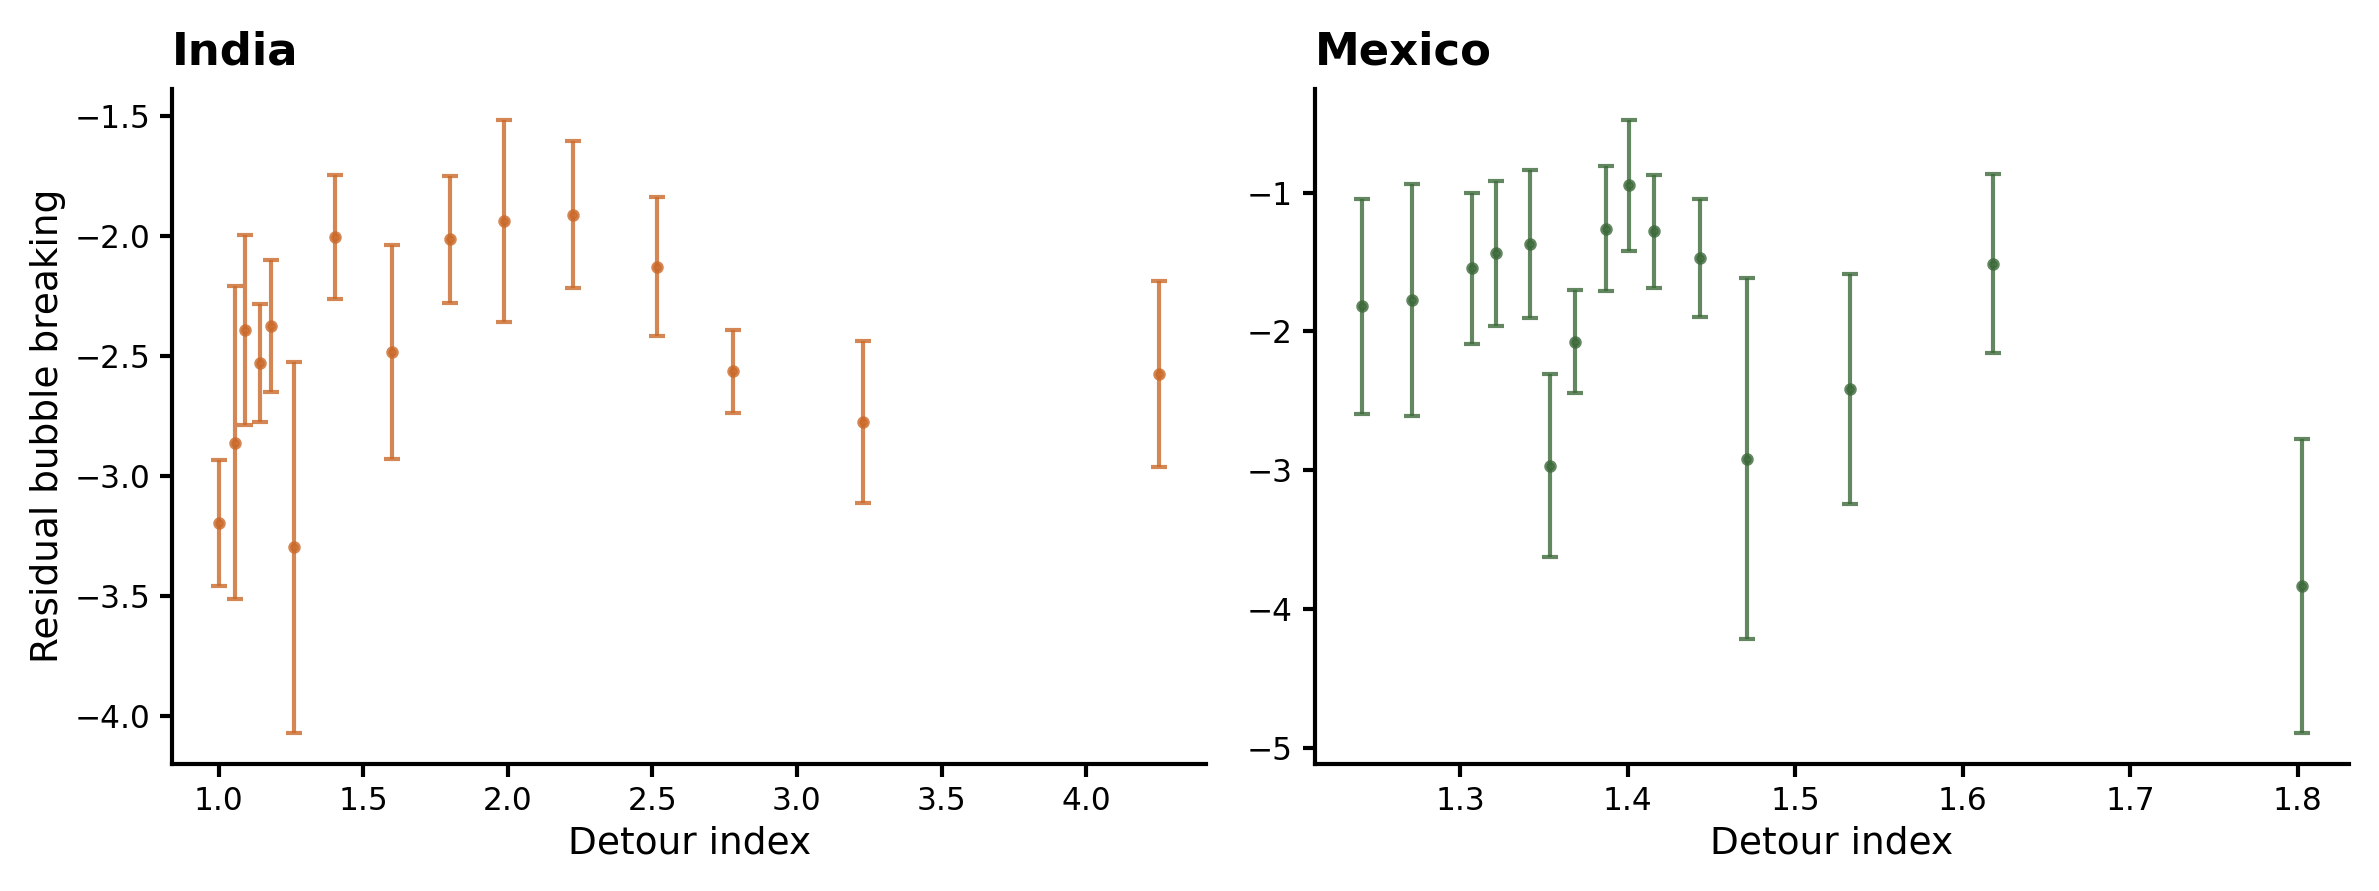

In [ ]:
bubble_breaking_gap_plot(data=bubble_breaking_gap_contrast_data(dfg=df_raw[df_raw['bb_g'] < 0], num_grp=15, x_var="detour"), var="detour", x_label='Detour index')